<a href="https://colab.research.google.com/github/Risha-art/ML-Final/blob/main/FINAL_MODEL_ATTEMPT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the important stuff

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import itertools
import gzip
import os
import io



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Getting the data and cleaning the data

Getting the NOAA data all sorted

In [ ]:
input_gz_file_pressure = '/content/drive/MyDrive/1.C01 ML Final Project/Data/44013Pressure2025.txt.gz'

#AI help with the file reading..
# Read content from the gzipped text file
content_pressure = []
df_pressure = None # Initialize df_pressure to None
try:
    with gzip.open(input_gz_file_pressure, 'rt', encoding='utf-8') as f:
        for line in f:
            content_pressure.append(line.strip())

    if content_pressure:
        data_pressure = io.StringIO('\n'.join(content_pressure))
        df_pressure = pd.read_csv(data_pressure, sep=r'\s+', header=0, skiprows=[1], engine='python')


        # columns from the 'df_pressure' DataFrame
        selected_columns_df_pressure = df_pressure[['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'PRES', 'ATMP']]

        df_44013 = selected_columns_df_pressure
except Exception as e:
    df_44013 = pd.DataFrame() # Initialize df_44013 as empty if an error occurs
display(df_44013.head())

,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,PRES,ATMP
0,2025,1,1,0,0,169,4.7,5.9,1012.6,7.0
1,2025,1,1,0,10,167,4.7,5.7,1012.6,7.0
2,2025,1,1,0,20,169,4.6,5.6,1012.6,7.0
3,2025,1,1,0,30,165,4.7,5.5,1012.8,6.9
4,2025,1,1,0,40,163,4.7,5.9,1012.6,6.9


getting BC data sorted

In [ ]:

input_csv_file_bc = '/content/drive/MyDrive/1.C01 ML Final Project/Data/BC2025.csv'
df_BC = pd.read_csv(input_csv_file_bc)

df_BC['Timestamp'] = pd.to_datetime(df_BC['Timestamp'])
df_BC['year'] = df_BC['Timestamp'].dt.year
df_BC['month'] = df_BC['Timestamp'].dt.month
df_BC['day'] = df_BC['Timestamp'].dt.day
df_BC['hour'] = df_BC['Timestamp'].dt.hour
df_BC['minute'] = df_BC['Timestamp'].dt.minute


# Rename columns in df_BC to match the correct format
df_BC_formatted = df_BC.rename(columns={
    'year': '#YY',
    'month': 'MM',
    'day': 'DD',
    'hour': 'hh',
    'minute': 'mm',
    'Wind Vane': 'WDIR',
    'Anemometer': 'WSPD',
    '10 Minute Wind Gust': 'GST',
    'Barometer': 'PRES',
    'Thermometer': 'ATMP'
})

# pick and reorder collombs
target_columns = ['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'PRES', 'ATMP']
df_BC_formatted = df_BC_formatted[target_columns]


# Unit conversions
df_BC_formatted['WSPD'] = df_BC_formatted['WSPD'] * 0.44704
df_BC_formatted['GST'] = df_BC_formatted['GST'] * 0.44704
df_BC_formatted['PRES'] = df_BC_formatted['PRES'] * 33.8639
df_BC_formatted['ATMP'] = (df_BC_formatted['ATMP'] - 32) * 5/9

df_BC_formatted.head()


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,PRES,ATMP
0,2025,1,1,12,29,342,1.78816,3.57632,991.331809,8.5
1,2025,1,1,12,30,342,2.23520,3.57632,991.365672,8.5
2,2025,1,1,12,30,311,2.68224,3.57632,991.399536,8.5
3,2025,1,1,12,31,291,0.44704,3.57632,991.297945,8.5
4,2025,1,1,12,33,311,1.34112,3.57632,991.399536,8.5


NEU now


In [ ]:
input_csv_file_neu = '/content/drive/MyDrive/1.C01 ML Final Project/Data/NEU2025.csv'
df_NEU = pd.read_csv(input_csv_file_neu)


df_NEU['Timestamp'] = pd.to_datetime(df_NEU['Timestamp'])
df_NEU['year'] = df_NEU['Timestamp'].dt.year
df_NEU['month'] = df_NEU['Timestamp'].dt.month
df_NEU['day'] = df_NEU['Timestamp'].dt.day
df_NEU['hour'] = df_NEU['Timestamp'].dt.hour
df_NEU['minute'] = df_NEU['Timestamp'].dt.minute

# Rename columns in df_NEU to match the correct format
df_NEU_formatted = df_NEU.rename(columns={
    'year': '#YY',
    'month': 'MM',
    'day': 'DD',
    'hour': 'hh',
    'minute': 'mm',
    'Wind Vane': 'WDIR',
    'Anemometer': 'WSPD',
    '10 Minute Wind Gust': 'GST',
    'Barometer': 'PRES',
    'Thermometer': 'ATMP'
})

# Select collombs
target_columns = ['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'PRES', 'ATMP']
df_NEU_formatted = df_NEU_formatted[target_columns]


# Conversions
df_NEU_formatted['WSPD'] = df_NEU_formatted['WSPD'] * 0.44704
df_NEU_formatted['GST'] = df_NEU_formatted['GST'] * 0.44704
df_NEU_formatted['PRES'] = df_NEU_formatted['PRES'] * 33.8639
df_NEU_formatted['ATMP'] = (df_NEU_formatted['ATMP'] - 32) * 5/9

df_NEU_formatted.head()


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,PRES,ATMP
0,2025,1,1,12,29,359,2.68224,4.02336,993.058868,8.500000
1,2025,1,1,12,30,359,0.44704,4.02336,993.025004,8.500000
2,2025,1,1,12,31,359,0.44704,4.02336,992.957276,8.500000
3,2025,1,1,12,32,359,0.89408,4.02336,992.991140,8.500000
4,2025,1,1,12,33,17,0.44704,4.02336,993.025004,8.444444


now swampscott

In [ ]:
input_csv_file_swamp = '/content/drive/MyDrive/1.C01 ML Final Project/Data/Swamp2025.csv'
df_SWAMP = pd.read_csv(input_csv_file_swamp)


df_SWAMP['Timestamp'] = pd.to_datetime(df_SWAMP['Timestamp'])
df_SWAMP['year'] = df_SWAMP['Timestamp'].dt.year
df_SWAMP['month'] = df_SWAMP['Timestamp'].dt.month
df_SWAMP['day'] = df_SWAMP['Timestamp'].dt.day
df_SWAMP['hour'] = df_SWAMP['Timestamp'].dt.hour
df_SWAMP['minute'] = df_SWAMP['Timestamp'].dt.minute


# Rename columns for correct format
df_SWAMP_formatted = df_SWAMP.rename(columns={
    'year': '#YY',
    'month': 'MM',
    'day': 'DD',
    'hour': 'hh',
    'minute': 'mm',
    'Wind Vane': 'WDIR',
    'Anemometer': 'WSPD',
    '10 Minute Wind Gust': 'GST',
    'Barometer': 'PRES',
    'Thermometer': 'ATMP'
})

# Select desired columns
target_columns = ['#YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'PRES', 'ATMP']
df_SWAMP_formatted = df_SWAMP_formatted[target_columns]


# conversoins
df_SWAMP_formatted['WSPD'] = df_SWAMP_formatted['WSPD'] * 0.44704
df_SWAMP_formatted['GST'] = df_SWAMP_formatted['GST'] * 0.44704
df_SWAMP_formatted['PRES'] = df_SWAMP_formatted['PRES'] * 33.8639
df_SWAMP_formatted['ATMP'] = (df_SWAMP_formatted['ATMP'] - 32) * 5/9


df_SWAMP_formatted.head()


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,PRES,ATMP
0,2025,1,1,12,50,9,1.78816,5.36448,993.905465,7.333333
1,2025,1,1,12,51,11,4.47040,5.36448,993.871601,7.333333
2,2025,1,1,12,52,348,2.23520,5.36448,993.939329,7.277778
3,2025,1,1,12,53,11,3.57632,5.36448,993.871601,7.277778
4,2025,1,1,12,54,13,3.57632,5.36448,993.905465,7.277778


now MIT

In [ ]:
input_csv_file_mit = '/content/drive/MyDrive/1.C01 ML Final Project/Data/MIT2025.csv'
df_MIT = pd.read_csv(input_csv_file_mit)

df_MIT['Timestamp'] = pd.to_datetime(df_MIT['Time'], format='%m/%d/%y %H:%M')
df_MIT['year'] = df_MIT['Timestamp'].dt.year
df_MIT['month'] = df_MIT['Timestamp'].dt.month
df_MIT['day'] = df_MIT['Timestamp'].dt.day
df_MIT['hour'] = df_MIT['Timestamp'].dt.hour
df_MIT['minute'] = df_MIT['Timestamp'].dt.minute

df_MIT_formatted = df_MIT.rename(columns={
    'year': '#YY',
    'month': 'MM',
    'day': 'DD',
    'hour': 'hh',
    'minute': 'mm',
    'Direction': 'WDIR',
    'wind speed': 'WSPD',
    'gust': 'GST',
    'Pressure': 'PRES',
    'Temp': 'ATMP'
})


# getting desired colombs
target_columns = ['#YY', 'MM', 'DD', 'hh', 'mm', 'WSPD', 'GST', 'PRES', 'ATMP', 'WDIR']

df_MIT_formatted = df_MIT_formatted[target_columns]


# Clean and convert 'WSPD' and 'GST' columns to numeric for units
df_MIT_formatted['WSPD'] = df_MIT_formatted['WSPD'].astype(str).str.replace(' km/h', '').astype(float)
df_MIT_formatted['GST'] = df_MIT_formatted['GST'].astype(str).str.replace(' km/h', '').astype(float)

# Conversions
df_MIT_formatted['WSPD'] = df_MIT_formatted['WSPD'] * (1000/3600)
df_MIT_formatted['GST'] = df_MIT_formatted['GST'] * (1000/3600)
df_MIT_formatted['PRES'] = df_MIT_formatted['PRES'].astype(float)
df_MIT_formatted['ATMP'] = df_MIT_formatted['ATMP'].astype(str).str.replace(' °C', '').astype(float)

df_MIT_formatted.head()


,#YY,MM,DD,hh,mm,WSPD,GST,PRES,ATMP,WDIR
0,2024.0,12.0,31.0,19.0,0.0,6.166667,9.083333,1004.0,7.46,52.5
1,2025.0,1.0,1.0,1.0,0.0,4.527778,7.250000,1000.0,8.06,49.4
2,2025.0,1.0,1.0,7.0,0.0,1.777778,3.388889,995.0,8.41,154.0
3,2025.0,1.0,1.0,13.0,0.0,2.316667,4.416667,995.0,7.84,243.0
4,2025.0,1.0,1.0,19.0,0.0,4.166667,8.750000,996.0,5.97,243.0


**merging** the dataframes

In [ ]:


#44013 and BC
# List of columns to join on
join_keys = ['#YY', 'MM', 'DD', 'hh', 'mm']

# Merging two dataframes
merged_df = pd.merge(df_44013, df_BC_formatted, on=join_keys, how='outer', suffixes=('_44013', '_BC'))

display(merged_df.head())

#Previous 2 and NEU
# List of columns to join on
join_keys = ['#YY', 'MM', 'DD', 'hh', 'mm']

# Merging two dataframes
merged_df1 = pd.merge(merged_df, df_NEU_formatted, on=join_keys, how='outer', suffixes=("_old",'_NEU'))

display(merged_df1.head())

#Previous 3 and SWAMP
# List of columns to join on
join_keys = ['#YY', 'MM', 'DD', 'hh', 'mm']

# Merging two dataframes
merged_df2 = pd.merge(merged_df1, df_SWAMP_formatted, on=join_keys, how='outer', suffixes=('_NEU', '_SWAMP'))

display(merged_df2.head())


#Previous 4 and MIT
# List of columns to join on
join_keys = ['#YY', 'MM', 'DD', 'hh', 'mm']

# Merging two dataframes
merged_df3 = pd.merge(merged_df2, df_MIT_formatted, on=join_keys, how='outer', suffixes=('_SWAMP', '_MIT'))

display(merged_df3.head())


merged_df3_cleaned = merged_df3.copy()




,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,WDIR_BC,WSPD_BC,GST_BC,PRES_BC,ATMP_BC
0,2025,1,1,0,0,169.0,4.7,5.9,1012.6,7.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,0,10,167.0,4.7,5.7,1012.6,7.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,0,20,169.0,4.6,5.6,1012.6,7.0,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,0,30,165.0,4.7,5.5,1012.8,6.9,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,0,40,163.0,4.7,5.9,1012.6,6.9,NaN,NaN,NaN,NaN,NaN


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,WDIR_BC,WSPD_BC,GST_BC,PRES_BC,ATMP_BC,WDIR,WSPD,GST,PRES,ATMP
0,2025,1,1,0,0,169.0,4.7,5.9,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,0,10,167.0,4.7,5.7,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,0,20,169.0,4.6,5.6,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,0,30,165.0,4.7,5.5,1012.8,6.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,0,40,163.0,4.7,5.9,1012.6,6.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,WDIR_NEU,WSPD_NEU,GST_NEU,PRES_NEU,ATMP_NEU,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP
0,2025,1,1,0,0,169.0,4.7,5.9,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,0,10,167.0,4.7,5.7,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,0,20,169.0,4.6,5.6,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,0,30,165.0,4.7,5.5,1012.8,6.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,0,40,163.0,4.7,5.9,1012.6,6.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
0,2024.0,12.0,31.0,19.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
1,2025.0,1.0,1.0,0.0,0.0,169.0,4.7,5.9,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025.0,1.0,1.0,0.0,10.0,167.0,4.7,5.7,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,1.0,1.0,0.0,20.0,169.0,4.6,5.6,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025.0,1.0,1.0,0.0,30.0,165.0,4.7,5.5,1012.8,6.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Fixing formatting of merged dataset

In [ ]:

#Fixing date format , with AI help
date_cols = ['#YY', 'MM', 'DD', 'hh', 'mm']
for col in date_cols:
    # Fill NaNs temporarily with a placeholder to allow astype(int), then convert to float
    merged_df3_cleaned[col] = merged_df3_cleaned[col].fillna(-1).astype(int).replace(-1, pd.NA)

# Drop rows where date components are still NA after conversion
merged_df3_cleaned.dropna(subset=date_cols, inplace=True)

# Convert to int again after dropping NA rows if needed, then to string
for col in date_cols:
    merged_df3_cleaned[col] = merged_df3_cleaned[col].astype(int).astype(str)

# Create a combined Timestamp string
merged_df3_cleaned['Timestamp'] = merged_df3_cleaned['#YY'] + '-' + \
                                  merged_df3_cleaned['MM'] + '-' + \
                                  merged_df3_cleaned['DD'] + ' ' + \
                                  merged_df3_cleaned['hh'] + ':' + \
                                  merged_df3_cleaned['mm']

# Convert the 'Timestamp' string to datetime objects
merged_df3_cleaned['Timestamp'] = pd.to_datetime(merged_df3_cleaned['Timestamp'], format='%Y-%m-%d %H:%M')

# Set 'Timestamp' as the index and sort the DataFrame
merged_df3_cleaned = merged_df3_cleaned.set_index('Timestamp').sort_index()

# Drop the individual date/time columns as they are now in the index
merged_df3_cleaned = merged_df3_cleaned.drop(columns=date_cols)


display(merged_df3_cleaned.head())



df_to_process = merged_df3_cleaned.copy()

#cleaning the rows, dropping ones missing ones where all columns from entiry group are missing

core_params = ['WSPD', 'GST', 'PRES', 'ATMP', 'WDIR']
param_columns = {param: [col for col in df_to_process.columns if param in col] for param in core_params}

rows_to_drop_mask = pd.Series(False, index=df_to_process.index)
for param, cols in param_columns.items():
    if cols:
        all_param_nan = df_to_process[cols].isnull().all(axis=1)
        rows_to_drop_mask = rows_to_drop_mask | all_param_nan

# Drop rows identified by the mask
df_filtered = df_to_process[~rows_to_drop_mask]




#replacing all NaN values with closest value
df_final_processed = df_filtered.bfill()

merged_df_final_processed = df_final_processed

# Resample to a 1-minute frequency (this will introduce NaNs for missing minutes)
# We use .mean() for aggregation, but for most columns it will just pick the existing value as it's already minute-level data
df_resampled = df_filtered.resample('1T').mean()

print("DataFrame after resampling to 1-minute frequency:")
display(df_resampled.head())


df_cleaned = merged_df3_cleaned.dropna(subset=['WSPD'])
display(df_cleaned.head())

,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,WDIR_BC,WSPD_BC,GST_BC,PRES_BC,ATMP_BC,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
2025-01-01 00:00:00,169.0,4.7,5.9,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:10:00,167.0,4.7,5.7,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:20:00,169.0,4.6,5.6,1012.6,7.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:30:00,165.0,4.7,5.5,1012.8,6.9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_2173/200968077.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_filtered.resample('1T').mean()


DataFrame after resampling to 1-minute frequency:


,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,WDIR_BC,WSPD_BC,GST_BC,PRES_BC,ATMP_BC,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
2024-12-31 19:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 19:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 19:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 19:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,WDIR_BC,WSPD_BC,GST_BC,PRES_BC,ATMP_BC,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
2025-01-01 01:00:00,159.0,4.3,5.4,1012.3,6.9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.527778,7.250000,1000.0,8.06,49.4
2025-01-01 07:00:00,107.0,9.6,11.8,1004.2,8.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.777778,3.388889,995.0,8.41,154.0
2025-01-01 13:00:00,80.0,5.3,7.0,997.2,7.9,NaN,NaN,NaN,NaN,NaN,...,18.0,2.23520,4.91744,993.803873,7.277778,2.316667,4.416667,995.0,7.84,243.0
2025-01-01 19:00:00,283.0,4.8,6.9,995.2,7.0,241.0,1.34112,3.57632,992.686365,7.388889,...,234.0,0.44704,1.34112,995.293885,4.833333,4.166667,8.750000,996.0,5.97,243.0


In [ ]:
df = merged_df3
display(df.head())

# Make a copy of the DataFrame
df_cleaned = df.copy()


#continuing to fix the forrmatting of the dataframe


# Create a datetime column from existing date and time components
df_cleaned['datetime'] = pd.to_datetime(
    df_cleaned['#YY'].astype(str).str.replace(r'\.0$', '', regex=True) + '-' +
    df_cleaned['MM'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2) + '-' +
    df_cleaned['DD'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2) + ' ' +
    df_cleaned['hh'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2) + ':' +
    df_cleaned['mm'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2),
    format='%Y-%m-%d %H:%M',
    errors='coerce'
)

#Set the new datetime column as the DataFrame index and sort it
df_cleaned = df_cleaned.set_index('datetime').sort_index()

# Remove rows where the datetime index is NaT
df_cleaned = df_cleaned[df_cleaned.index.notna()]

# Drop duplicate index entries keeping first one
df_cleaned = df_cleaned[~df_cleaned.index.duplicated(keep='first')]

# excluding any filling that is on the MIT wind collomb , and time
exclude_cols_exact = ['WSPD', 'GST', 'PRES', 'ATMP', 'WDIR']
original_date_time_cols = ['#YY', 'MM', 'DD', 'hh', 'mm']

# list of columns to have their NaNs filled
cols_to_fill = [
    col for col in df_cleaned.columns
    if col not in exclude_cols_exact and col not in original_date_time_cols
]


# Only fill if the replacement value's timestamp is within 10 minutes of the NaN's timestamp
#extra help from AI on this part
df_cleaned_temp = df_cleaned.copy()

for col in cols_to_fill:
    original_col = df_cleaned_temp[col]


    valid_mask = original_col.notna()
    valid_indices = original_col.index[valid_mask]

    time_to_last_valid = pd.Series(pd.NaT, index=df_cleaned_temp.index, dtype='timedelta64[ns]')
    time_to_next_valid = pd.Series(pd.NaT, index=df_cleaned_temp.index, dtype='timedelta64[ns]')

    if not valid_indices.empty:
        s_last_valid_idx = pd.Series(valid_indices, index=valid_indices).reindex(df_cleaned_temp.index, method='ffill')
        time_to_last_valid = df_cleaned_temp.index - s_last_valid_idx

        s_next_valid_idx = pd.Series(valid_indices, index=valid_indices).reindex(df_cleaned_temp.index, method='bfill')
        time_to_next_valid = s_next_valid_idx - df_cleaned_temp.index

    # Perform simple forward and backward fill on the column to get candidate values
    ffilled_col = original_col.ffill()
    bfilled_col = original_col.bfill()

    # Mask for original NaNs
    nan_mask = original_col.isna()

    temp_filled_col = original_col.copy()

    # Apply fills based on conditions for original NaNs

    # Condition for forward fill: it's within 10 min, AND (backward fill is not within 10 min OR forward fill is closer)
    ffill_cond = (time_to_last_valid <= pd.Timedelta('10 minutes')) & \
                 ((time_to_next_valid > pd.Timedelta('10 minutes')) | (time_to_last_valid <= time_to_next_valid))

    # Condition for backward fill: it's within 10 min, AND (forward fill is not within 10 min OR backward fill is closer)
    bfill_cond = (time_to_next_valid <= pd.Timedelta('10 minutes')) & \
                 ((time_to_last_valid > pd.Timedelta('10 minutes')) | (time_to_next_valid < time_to_last_valid))

    # Apply fills for NaNs based on these conditions
    temp_filled_col.loc[nan_mask & ffill_cond] = ffilled_col.loc[nan_mask & ffill_cond]
    temp_filled_col.loc[nan_mask & bfill_cond] = bfilled_col.loc[nan_mask & bfill_cond]

    # Assign the limit-filled column back to the temporary DataFrame
    df_cleaned_temp[col] = temp_filled_col

# update the original df_cleaned with the new limit-filled columns
df_cleaned[cols_to_fill] = df_cleaned_temp[cols_to_fill]

display(df_cleaned.head())

df_offset = df_cleaned.copy()




## offsetting the collombs
# Columns to be offset
offset_cols = ['WDIR', 'WSPD', 'GST']

for col in offset_cols:
    temp_series = df_offset[col].copy()
    temp_series.index = df_offset.index + pd.Timedelta(minutes=30)
    df_offset[f'{col}_offset_30min'] = temp_series.reindex(df_offset.index)

# Columns to remove
columns_to_drop = ['WSPD', 'GST', 'PRES', 'ATMP', 'WDIR']
df_final = df_offset.drop(columns=columns_to_drop)

# Drop all rows that still contain any NaN values
df_final_no_nan = df_final.dropna()
df_final_no_nan.head()



,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
0,2024.0,12.0,31.0,19.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
1,2025.0,1.0,1.0,0.0,0.0,169.0,4.7,5.9,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025.0,1.0,1.0,0.0,10.0,167.0,4.7,5.7,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,1.0,1.0,0.0,20.0,169.0,4.6,5.6,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025.0,1.0,1.0,0.0,30.0,165.0,4.7,5.5,1012.8,6.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WSPD,GST,PRES,ATMP,WDIR
datetime,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,2024.0,12.0,31.0,19.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.166667,9.083333,1004.0,7.46,52.5
2025-01-01 00:00:00,2025.0,1.0,1.0,0.0,0.0,169.0,4.7,5.9,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:10:00,2025.0,1.0,1.0,0.0,10.0,167.0,4.7,5.7,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:20:00,2025.0,1.0,1.0,0.0,20.0,169.0,4.6,5.6,1012.6,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:30:00,2025.0,1.0,1.0,0.0,30.0,165.0,4.7,5.5,1012.8,6.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,PRES_NEU,ATMP_NEU,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WDIR_offset_30min,WSPD_offset_30min,GST_offset_30min
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 13:30:00,2025.0,1.0,1.0,13.0,30.0,66.0,5.6,7.0,996.8,7.8,...,992.957276,8.444444,319.0,2.23520,3.57632,993.939329,7.333333,243.0,2.316667,4.416667
2025-01-01 19:30:00,2025.0,1.0,1.0,19.0,30.0,283.0,6.7,9.1,995.4,6.8,...,994.244104,8.000000,228.0,1.34112,4.91744,995.090702,5.777778,243.0,4.166667,8.750000
2025-01-02 01:30:00,2025.0,1.0,2.0,1.0,30.0,270.0,9.8,12.9,997.3,6.6,...,995.801843,4.722222,214.0,5.36448,11.62304,996.242074,3.888889,244.0,4.694444,9.500000
2025-01-02 07:30:00,2025.0,1.0,2.0,7.0,30.0,259.0,12.8,16.6,999.0,4.9,...,999.696192,3.666667,240.0,9.83488,11.62304,999.899375,2.333333,251.0,5.222222,11.500000
2025-01-02 13:30:00,2025.0,1.0,2.0,13.0,30.0,271.0,16.2,20.8,1002.6,4.1,...,1001.050748,6.222222,352.0,3.57632,12.07008,1001.558706,5.444444,240.0,5.555556,11.194444


making season colomb

In [ ]:
thedata_df = df_final_no_nan
thedataseason = thedata_df.copy()

def get_season(month):
    if month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    elif month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    else:
        return 'Unknown'

#making season collomb
thedataseason['MM'] = thedataseason['MM'].astype(int)
thedataseason['Season'] = thedataseason['MM'].apply(get_season)

display(thedataseason.head())

,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,ATMP_NEU,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WDIR_offset_30min,WSPD_offset_30min,GST_offset_30min,Season
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 13:30:00,2025.0,1,1.0,13.0,30.0,66.0,5.6,7.0,996.8,7.8,...,8.444444,319.0,2.23520,3.57632,993.939329,7.333333,243.0,2.316667,4.416667,Winter
2025-01-01 19:30:00,2025.0,1,1.0,19.0,30.0,283.0,6.7,9.1,995.4,6.8,...,8.000000,228.0,1.34112,4.91744,995.090702,5.777778,243.0,4.166667,8.750000,Winter
2025-01-02 01:30:00,2025.0,1,2.0,1.0,30.0,270.0,9.8,12.9,997.3,6.6,...,4.722222,214.0,5.36448,11.62304,996.242074,3.888889,244.0,4.694444,9.500000,Winter
2025-01-02 07:30:00,2025.0,1,2.0,7.0,30.0,259.0,12.8,16.6,999.0,4.9,...,3.666667,240.0,9.83488,11.62304,999.899375,2.333333,251.0,5.222222,11.500000,Winter
2025-01-02 13:30:00,2025.0,1,2.0,13.0,30.0,271.0,16.2,20.8,1002.6,4.1,...,6.222222,352.0,3.57632,12.07008,1001.558706,5.444444,240.0,5.555556,11.194444,Winter


In [ ]:
thedata = thedataseason

#thedata = pd.read_csv('/content/drive/MyDrive/thedataseason_with_seasons.csv') #file path for NAT: /content/drive/MyDrive/1.C01 ML Final Project/Data/thedataseason_with_seasons.csv

In [ ]:
cols_outlier_removal = [
    'WSPD_offset_30min', 'GST_offset_30min',
    'WSPD_44013', 'GST_44013',
    'WSPD_BC', 'GST_BC',
    'WSPD_NEU', 'GST_NEU',
    'WSPD_SWAMP', 'GST_SWAMP',
    'PRES_44013', 'ATMP_44013',
    'PRES_BC', 'ATMP_BC',
    'PRES_NEU', 'ATMP_NEU',
    'ATMP_SWAMP'
]


initial_rows = thedata.shape[0]

thedata_cleaned = thedata.copy()

for col in cols_outlier_removal:
    if col in thedata_cleaned.columns:
        Q1 = thedata_cleaned[col].quantile(0.25)
        Q3 = thedata_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3.0 * IQR
        upper_bound = Q3 + 3.0 * IQR

        outliers_before_removal = thedata_cleaned.shape[0]
        thedata_cleaned = thedata_cleaned[(thedata_cleaned[col] >= lower_bound) & (thedata_cleaned[col] <= upper_bound)]
        removed_rows_from_col = outliers_before_removal - thedata_cleaned.shape[0]

thedata = thedata_cleaned

Dealing with the Swampscott values where pressure = 0

In [ ]:
# Replace 0 values in PRES_SWAMP with NaN
original_zeros = (thedata['PRES_SWAMP'] == 0).sum()
if original_zeros > 0:
    thedata['PRES_SWAMP'] = thedata['PRES_SWAMP'].replace(0, np.nan)

Organizing the data and variables

In [ ]:
thedata.head()

,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,ATMP_NEU,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WDIR_offset_30min,WSPD_offset_30min,GST_offset_30min,Season
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 13:30:00,2025.0,1,1.0,13.0,30.0,66.0,5.6,7.0,996.8,7.8,...,8.444444,319.0,2.23520,3.57632,993.939329,7.333333,243.0,2.316667,4.416667,Winter
2025-01-01 19:30:00,2025.0,1,1.0,19.0,30.0,283.0,6.7,9.1,995.4,6.8,...,8.000000,228.0,1.34112,4.91744,995.090702,5.777778,243.0,4.166667,8.750000,Winter
2025-01-02 01:30:00,2025.0,1,2.0,1.0,30.0,270.0,9.8,12.9,997.3,6.6,...,4.722222,214.0,5.36448,11.62304,996.242074,3.888889,244.0,4.694444,9.500000,Winter
2025-01-02 07:30:00,2025.0,1,2.0,7.0,30.0,259.0,12.8,16.6,999.0,4.9,...,3.666667,240.0,9.83488,11.62304,999.899375,2.333333,251.0,5.222222,11.500000,Winter
2025-01-02 13:30:00,2025.0,1,2.0,13.0,30.0,271.0,16.2,20.8,1002.6,4.1,...,6.222222,352.0,3.57632,12.07008,1001.558706,5.444444,240.0,5.555556,11.194444,Winter


# EDA

### Correlation Matrix of All Variables

### Correlation Matrix with Selected Features

A new correlation matrix heatmap will be generated using only the features you specified. This can help in focusing on the relationships between the most relevant variables for our model.

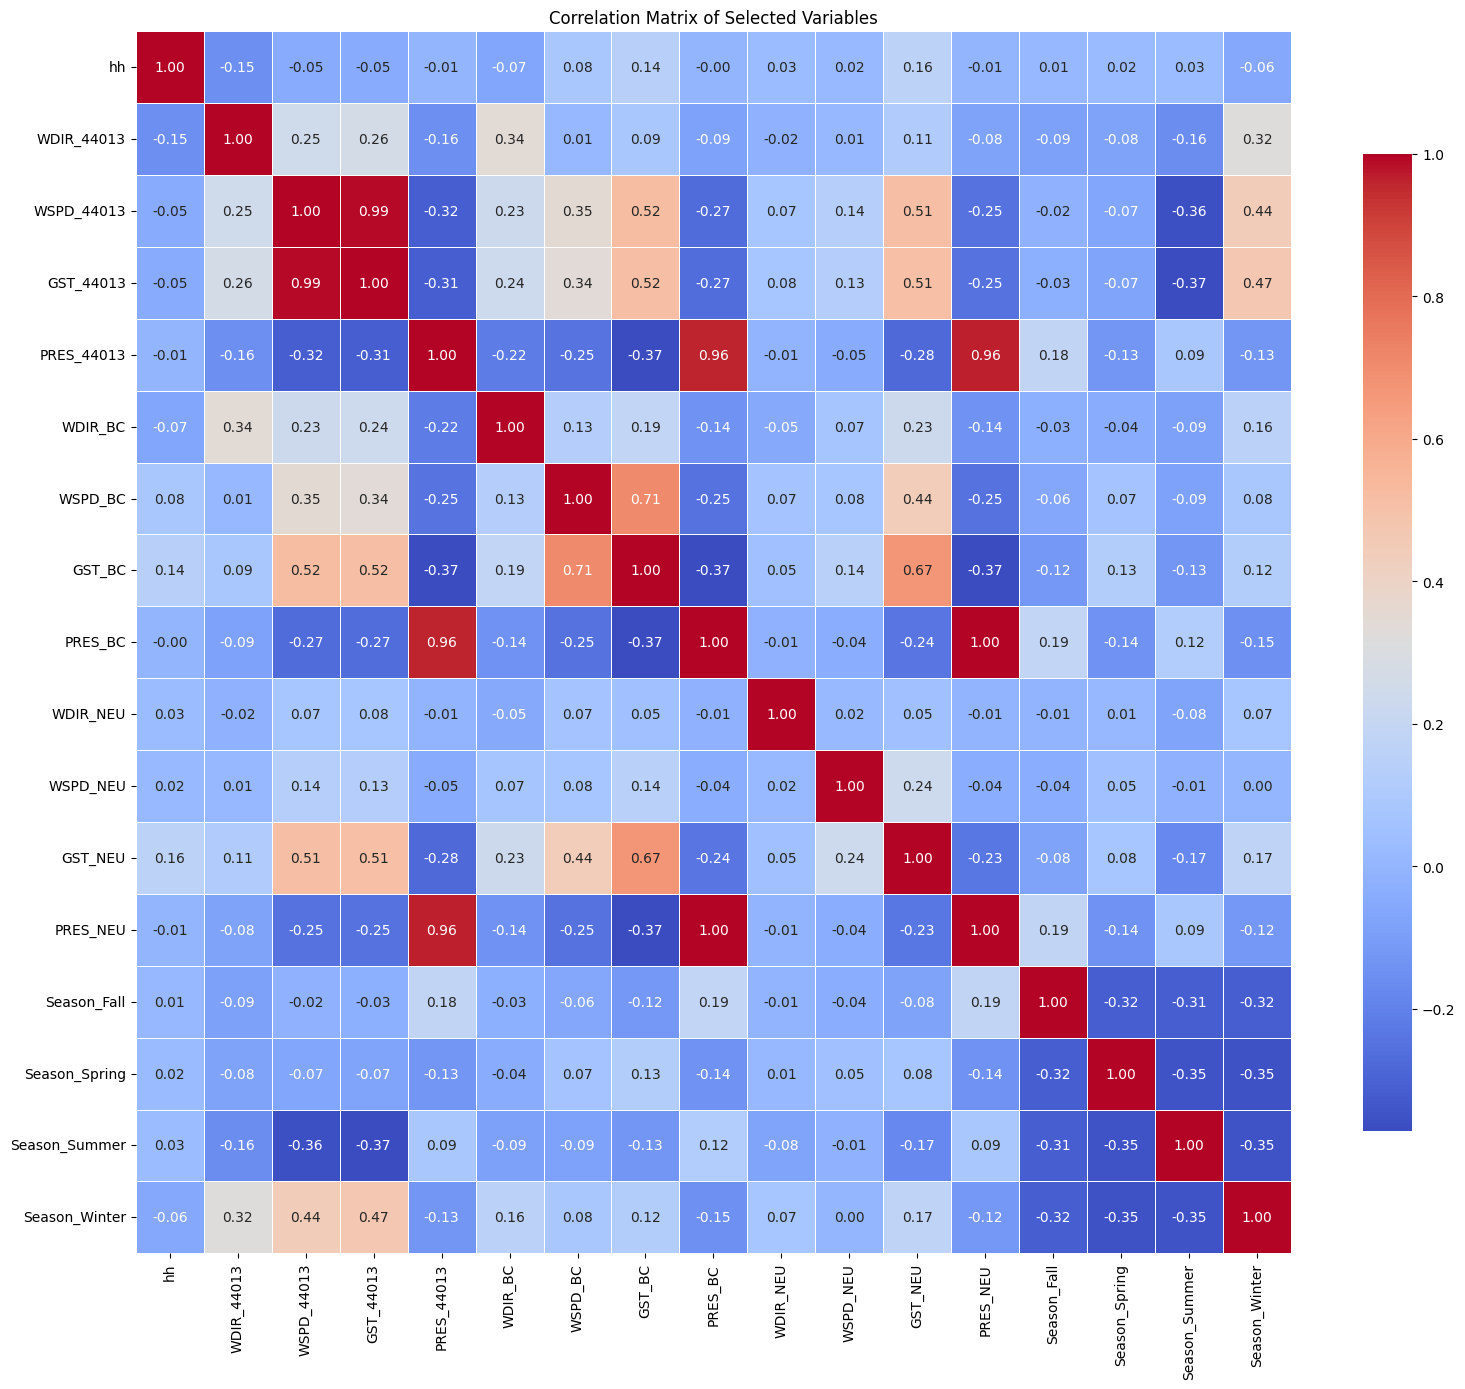

In [ ]:
selected_features = [
    "hh", "WDIR_44013", "WSPD_44013", "GST_44013", "PRES_44013",
    "WDIR_BC", "WSPD_BC", "GST_BC", "PRES_BC",
    "WDIR_NEU", "WSPD_NEU", "GST_NEU", "PRES_NEU",
    'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter'
]

#one-hot encoding for the 'Season' column in thedata
thedata = pd.get_dummies(thedata, columns=['Season'], prefix='Season', drop_first=False)

# Filter the one-hot encoded DataFrame
filtered_thedata = thedata_encoded[selected_features]

plt.figure(figsize=(16, 14))
correlation_matrix_selected = filtered_thedata.corr(numeric_only=True)
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Selected Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The following section is looking at variable distribution.

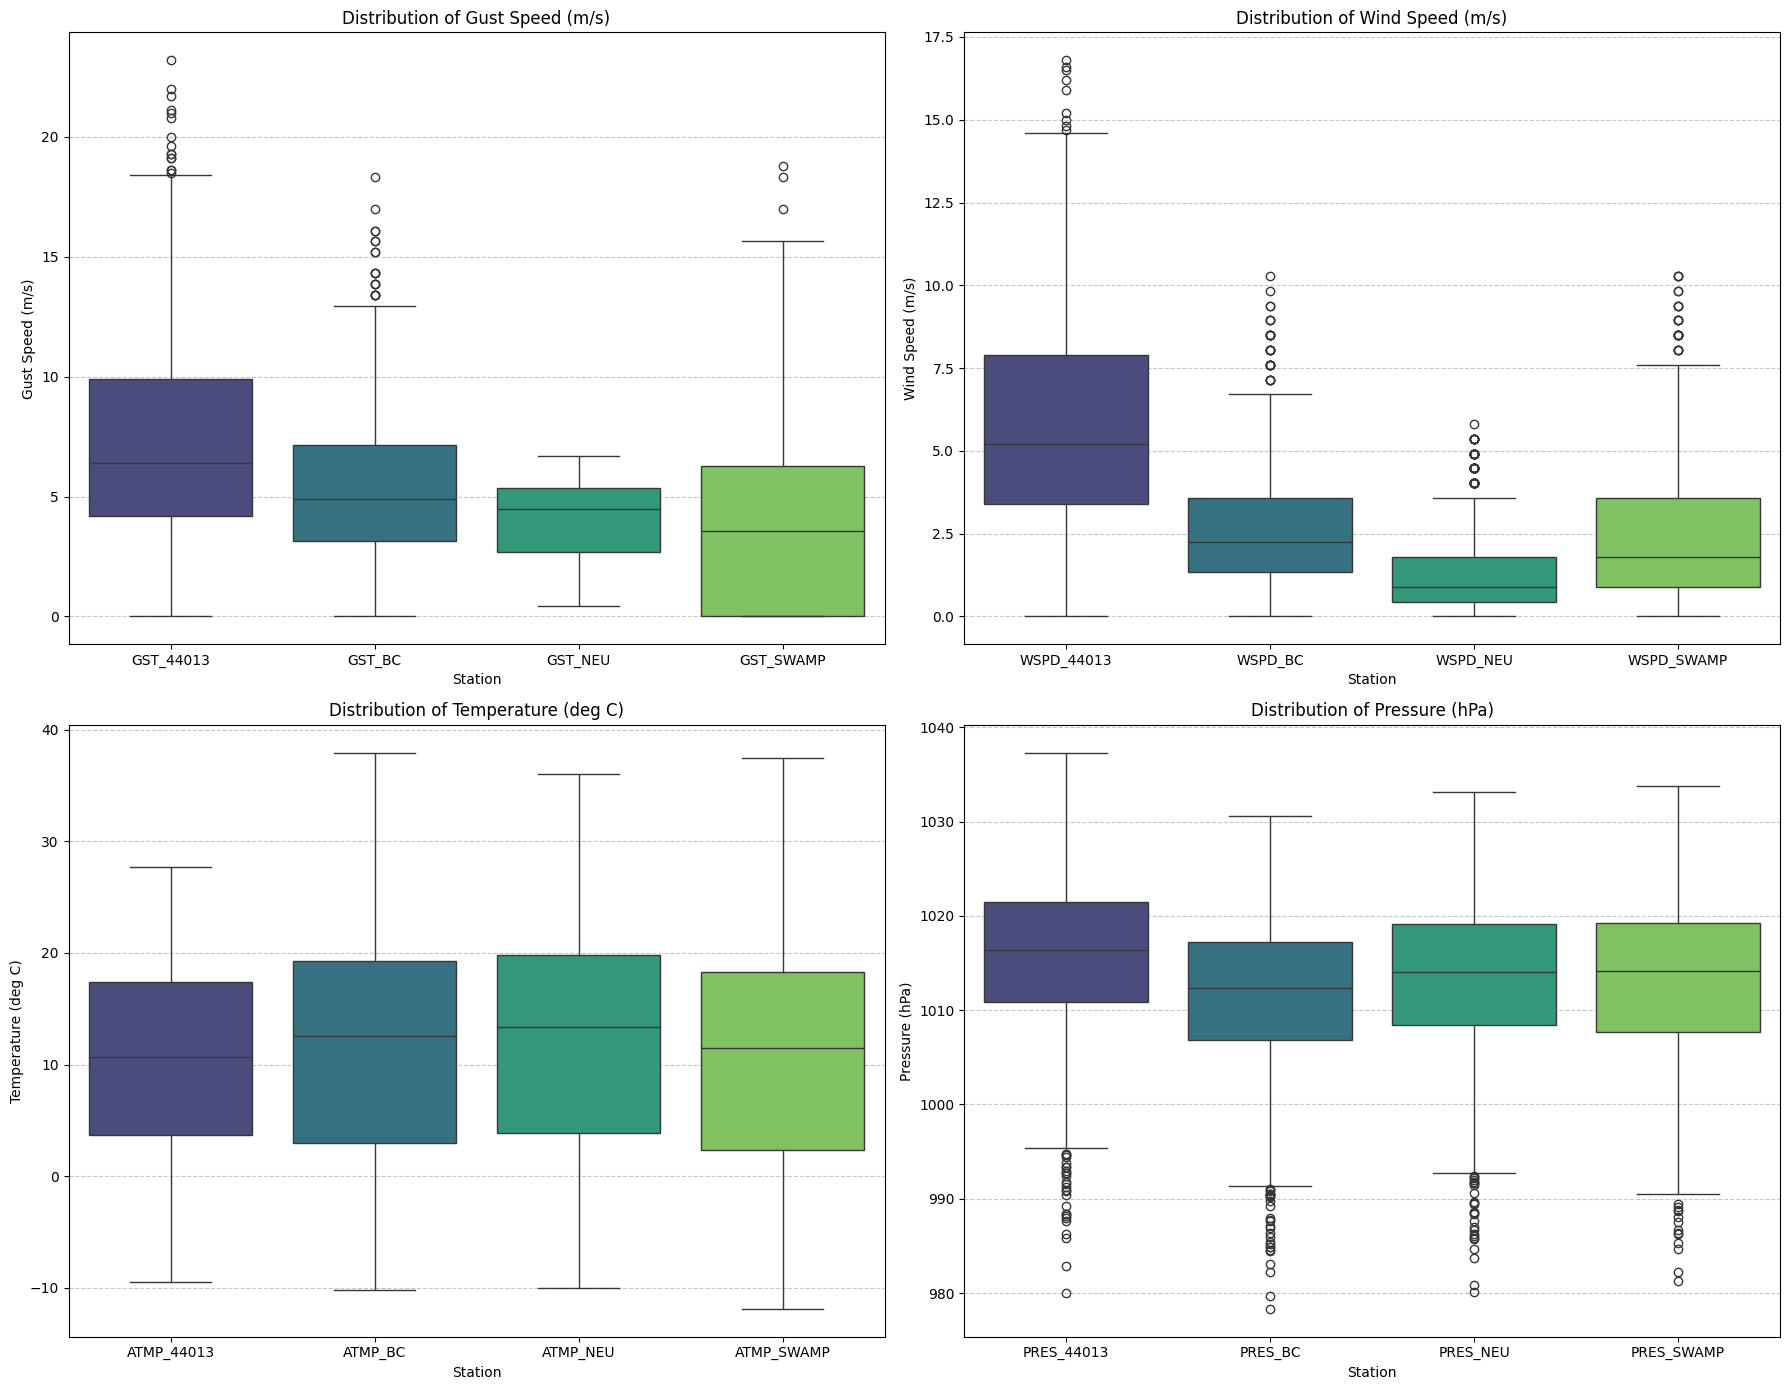

In [ ]:
# defining categories
plot_categories = {
    'Gust Speed (m/s)': ['GST_44013', 'GST_BC', 'GST_NEU', 'GST_SWAMP'],
    'Wind Speed (m/s)': ['WSPD_44013', 'WSPD_BC', 'WSPD_NEU', 'WSPD_SWAMP'],
    'Temperature (deg C)': ['ATMP_44013', 'ATMP_BC', 'ATMP_NEU', 'ATMP_SWAMP'],
    'Pressure (hPa)': ['PRES_44013', 'PRES_BC', 'PRES_NEU', 'PRES_SWAMP']
}

#figure formatting
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# loop for making plot
for i, (category, cols) in enumerate(plot_categories.items()):
    existing_cols = [col for col in cols if col in thedata.columns]

    if existing_cols:
        sns.boxplot(data=thedata[existing_cols], palette='viridis', ax=axes[i])
        axes[i].set_title(f'Distribution of {category}')
        axes[i].set_xlabel('Station')
        axes[i].set_ylabel(category)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

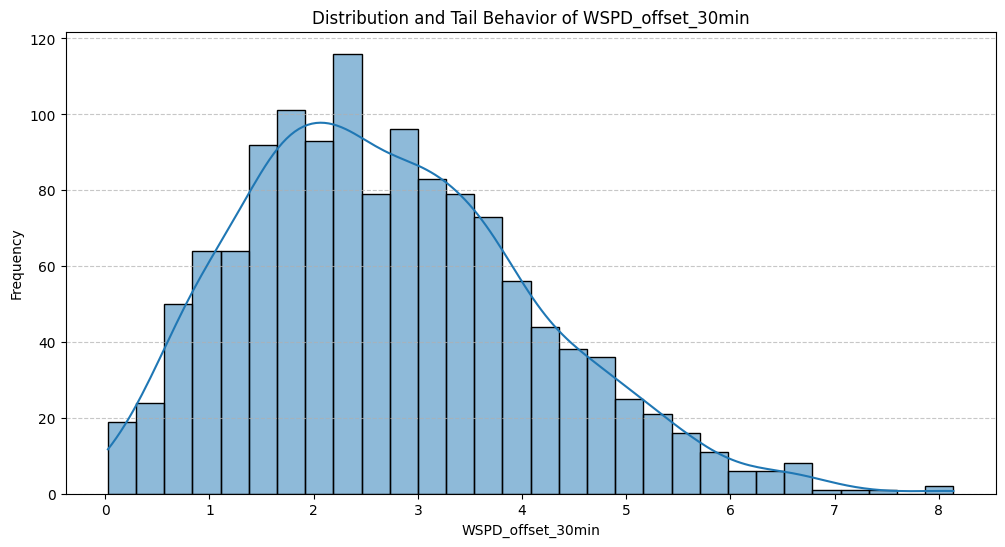

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(thedata['WSPD_offset_30min'], kde=True, bins=30)
plt.title('Distribution and Tail Behavior of WSPD_offset_30min')
plt.xlabel('WSPD_offset_30min')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of `WSPD_offset_30min` by Season

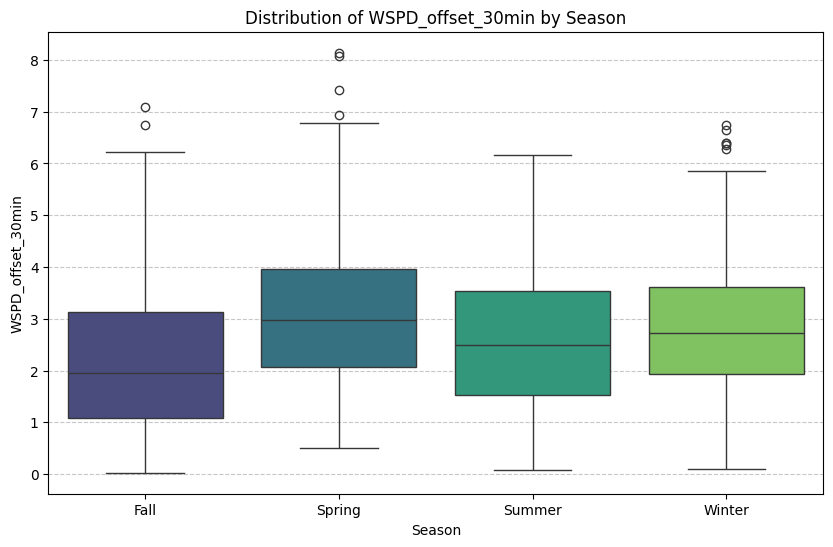

In [ ]:
season_cols = ['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']
season_names = [s.replace('Season_', '') for s in season_cols]

# prep data for plotting by season
season_data_long = pd.melt(thedata, id_vars=['WSPD_offset_30min'], value_vars=season_cols, var_name='Season_OneHot', value_name='Is_Season')
season_data_long = season_data_long[season_data_long['Is_Season'] == 1]
season_data_long['Season'] = season_data_long['Season_OneHot'].str.replace('Season_', '')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='WSPD_offset_30min', data=season_data_long, palette='viridis', order=season_names, hue='Season', legend=False)
plt.title('Distribution of WSPD_offset_30min by Season')
plt.xlabel('Season')
plt.ylabel('WSPD_offset_30min')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Average `WSPD_offset_30min` by Hour of the Day

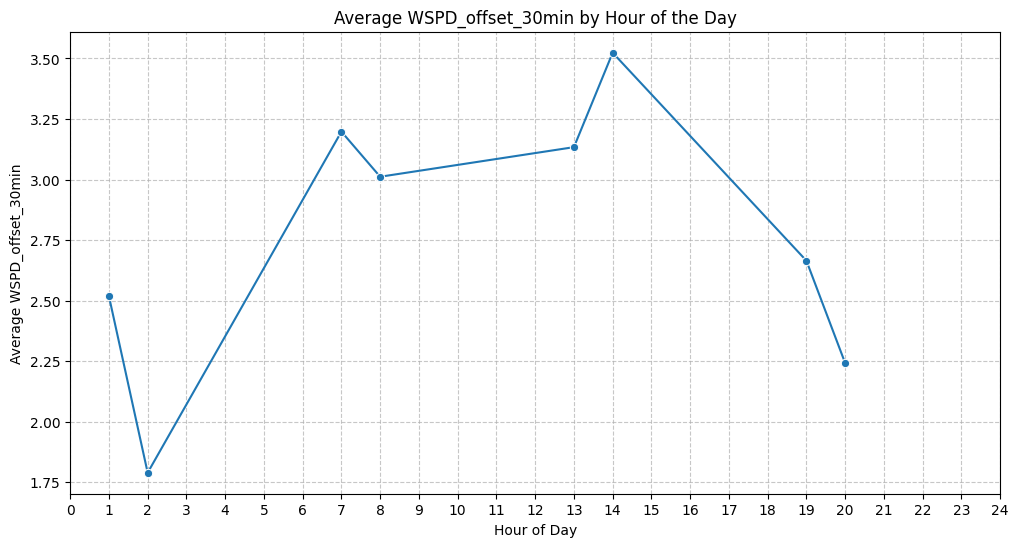

In [ ]:
hourly_avg_wspd = thedata.groupby('hh')['WSPD_offset_30min'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hh', y='WSPD_offset_30min', data=hourly_avg_wspd, marker='o')
plt.title('Average WSPD_offset_30min by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average WSPD_offset_30min')
plt.xticks(range(0, 25)) # Ensure all hours are displayed
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
hourly_data_counts = thedata.groupby('hh').size().reset_index(name='count')
print("Number of data points for each hour of the day:")
display(hourly_data_counts)
thedata.describe()

Number of data points for each hour of the day:


,hh,count
0,1.0,110
1,2.0,213
2,7.0,101
3,8.0,222
4,13.0,110
5,14.0,220
6,19.0,110
7,20.0,219


,#YY,MM,DD,hh,mm,WDIR_44013,WSPD_44013,GST_44013,PRES_44013,ATMP_44013,...,PRES_NEU,ATMP_NEU,WDIR_SWAMP,WSPD_SWAMP,GST_SWAMP,PRES_SWAMP,ATMP_SWAMP,WDIR_offset_30min,WSPD_offset_30min,GST_offset_30min
count,1305.0,1305.000000,1305.000000,1305.000000,1305.0,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,...,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,980.000000,1305.000000,1305.000000,1305.000000,1305.000000
mean,2025.0,6.325670,15.834483,10.727203,30.0,200.024521,5.808736,7.409042,1015.648506,10.029119,...,1013.213208,12.280332,177.436015,2.403397,4.200463,1013.065729,10.646062,190.751034,2.723234,4.910590
std,0.0,3.423864,8.960130,6.724696,0.0,93.877152,3.227744,4.167457,8.382743,7.827472,...,8.280148,9.910853,107.596151,1.975560,3.733442,8.720444,9.938227,70.492654,1.398098,2.304519
min,2025.0,1.000000,1.000000,1.000000,30.0,2.000000,0.000000,0.000000,980.000000,-9.500000,...,980.156722,-10.000000,0.000000,0.000000,0.000000,981.240366,-11.888889,30.900000,0.026472,0.167778
25%,2025.0,3.000000,8.000000,7.000000,30.0,137.000000,3.400000,4.200000,1010.900000,3.700000,...,1008.466942,3.888889,76.000000,0.894080,0.000000,1007.688072,2.333333,143.000000,1.683333,3.166667
50%,2025.0,6.000000,16.000000,13.000000,30.0,210.000000,5.200000,6.400000,1016.400000,10.700000,...,1014.020622,13.333333,205.000000,1.788160,3.576320,1014.156077,11.444444,213.000000,2.563889,4.611111
75%,2025.0,9.000000,24.000000,19.000000,30.0,278.000000,7.900000,9.900000,1021.500000,17.400000,...,1019.100207,19.777778,246.000000,3.576320,6.258560,1019.210264,18.333333,238.000000,3.611111,6.305556
max,2025.0,12.000000,31.000000,20.000000,30.0,360.000000,16.800000,23.200000,1037.300000,27.700000,...,1033.119861,36.000000,360.000000,10.281920,18.775680,1033.729411,37.444444,320.000000,8.138889,12.777778


### Distribution of Data Points by Season

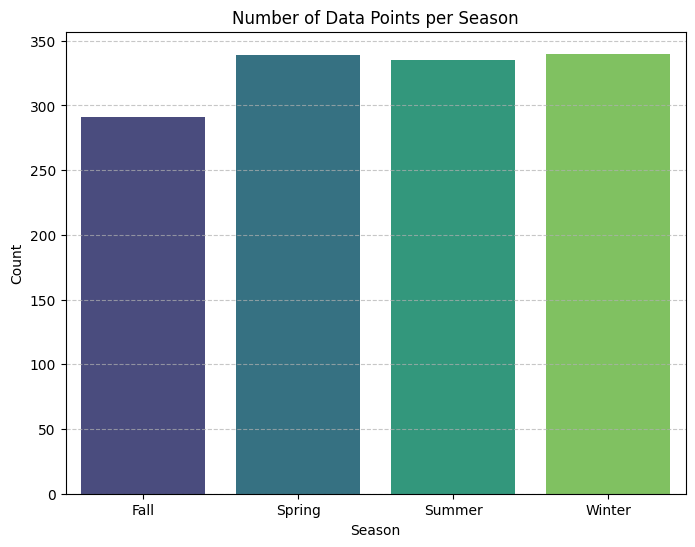

In [ ]:
# Calculate total counts for each season (assuming one-hot encoded 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter')
season_counts = thedata[['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']].sum()
season_counts.index = season_counts.index.str.replace('Season_', '')

plt.figure(figsize=(8, 6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis', hue=season_counts.index, legend=False)
plt.title('Number of Data Points per Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Data Points by Hour of the Day

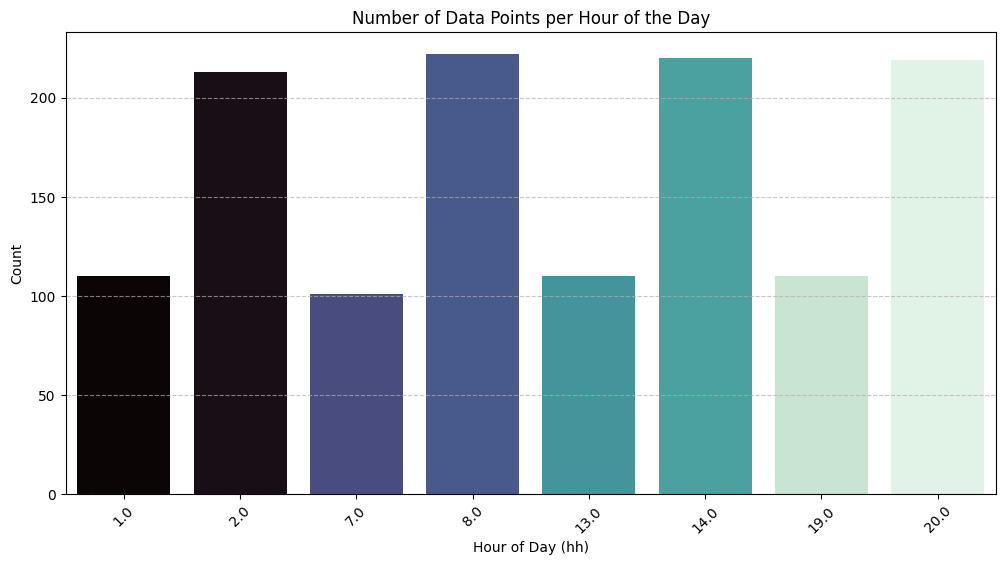

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='hh', y='count', data=hourly_data_counts, palette='mako', hue='hh', legend=False)
plt.title('Number of Data Points per Hour of the Day')
plt.xlabel('Hour of Day (hh)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

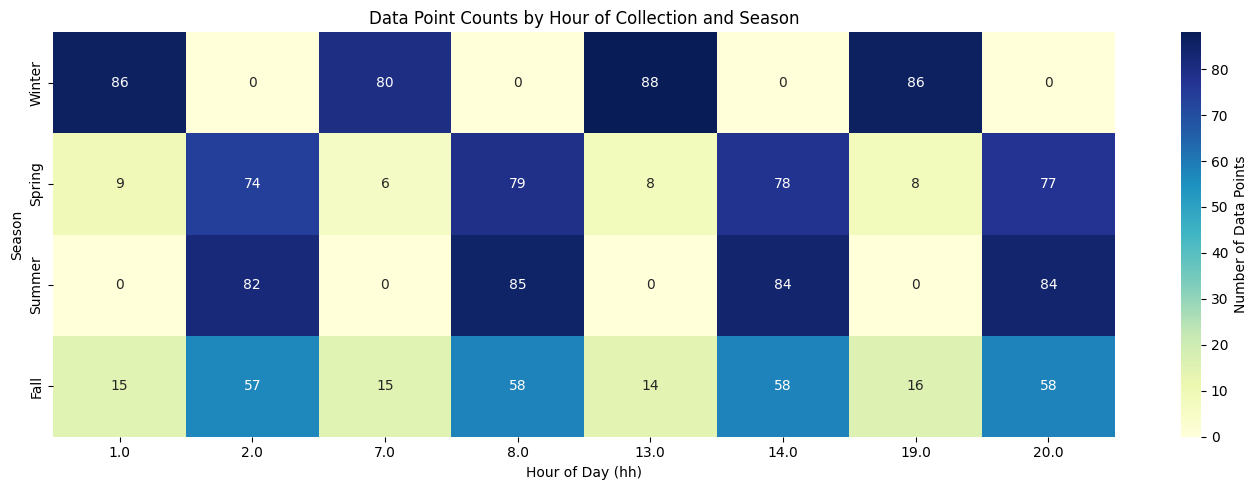

In [ ]:
# Heat Map of Hour of Collection vs. Season
# convert one-hot seasons back to a single column for easier plotting
season_cols = ['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']
thedata['Season'] = thedata[season_cols].idxmax(axis=1).str.replace('Season_', '')

pivot_counts = thedata.pivot_table(
    index='Season',
    columns='hh',
    values='WSPD_offset_30min',
    aggfunc='count',
    fill_value=0
)

# Reordered seasons so it would flow in a natural progression
pivot_counts = pivot_counts.reindex(['Winter', 'Spring', 'Summer', 'Fall'])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_counts, annot=True, fmt='d', cmap='YlGnBu',
            cbar_kws={'label': 'Number of Data Points'})
plt.title('Data Point Counts by Hour of Collection and Season')
plt.xlabel('Hour of Day (hh)')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

# The XGBOOST Model

In [ ]:
# Features we want to include
features = [
    "hh", "WDIR_44013", "WSPD_44013", "GST_44013", "PRES_44013",
    "WDIR_BC", "WSPD_BC", "GST_BC", "PRES_BC",
    "WDIR_NEU", "WSPD_NEU", "GST_NEU", "PRES_NEU",
    'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter',
    "ATMP_44013", "ATMP_BC", "ATMP_NEU", "ATMP_SWAMP"
]

# splitting data into x and y
X_full_df = thedata[features]
y_full_df = thedata["WSPD_offset_30min"]

# random train-test split
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_full_df, y_full_df, test_size=0.2, random_state=0)

# XGBoost and hyperparameters
xgbr = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=2,
    early_stopping_rounds=30
)

#train the model
xgbr.fit(X_train_df, y_train_df, eval_set=[(X_test_df, y_test_df)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# Exploring the model and results

Feature Importances:


,Feature,Importance
7,GST_BC,0.253695
0,hh,0.094670
6,WSPD_BC,0.093523
13,Season_Fall,0.059541
11,GST_NEU,0.057072
5,WDIR_BC,0.055652
14,Season_Spring,0.051394
1,WDIR_44013,0.045077
8,PRES_BC,0.041724
12,PRES_NEU,0.036728


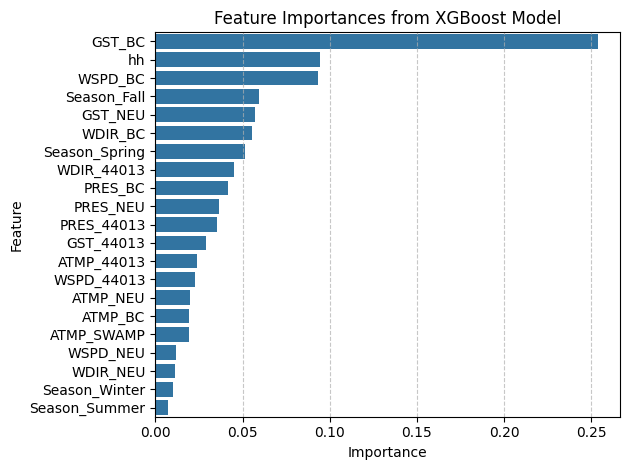

In [ ]:
# feature importances from the XGBoost model
feature_importances = xgbr.feature_importances_

feature_names = features

importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

# make in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

#plot of the importance
sns.barplot(x='Importance', y='Feature', data=importance_df, order=importance_df['Feature'])
plt.title('Feature Importances from XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Evaluating the model

In [ ]:
#getting y-pred
y_pred = xgbr.predict(X_test_df)

# getting classic equaluation metrics
mse = mean_squared_error(y_test_df, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_df, y_pred)
r2 = r2_score(y_test_df, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.7570
RMSE: 0.8700
R2: 0.5651


Residuals

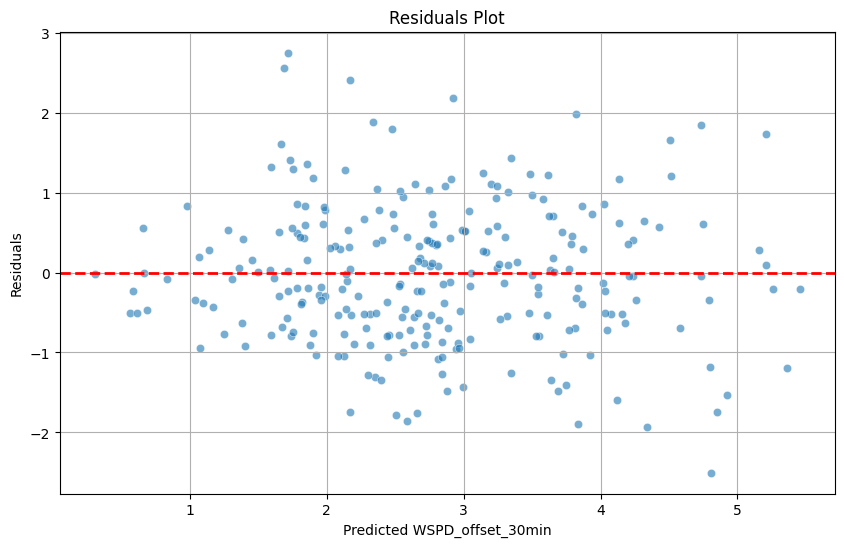

In [ ]:
# calculating residuals
residuals = y_test_df - y_pred
# plotting residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted WSPD_offset_30min')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True)
plt.show()

Checking Tree out

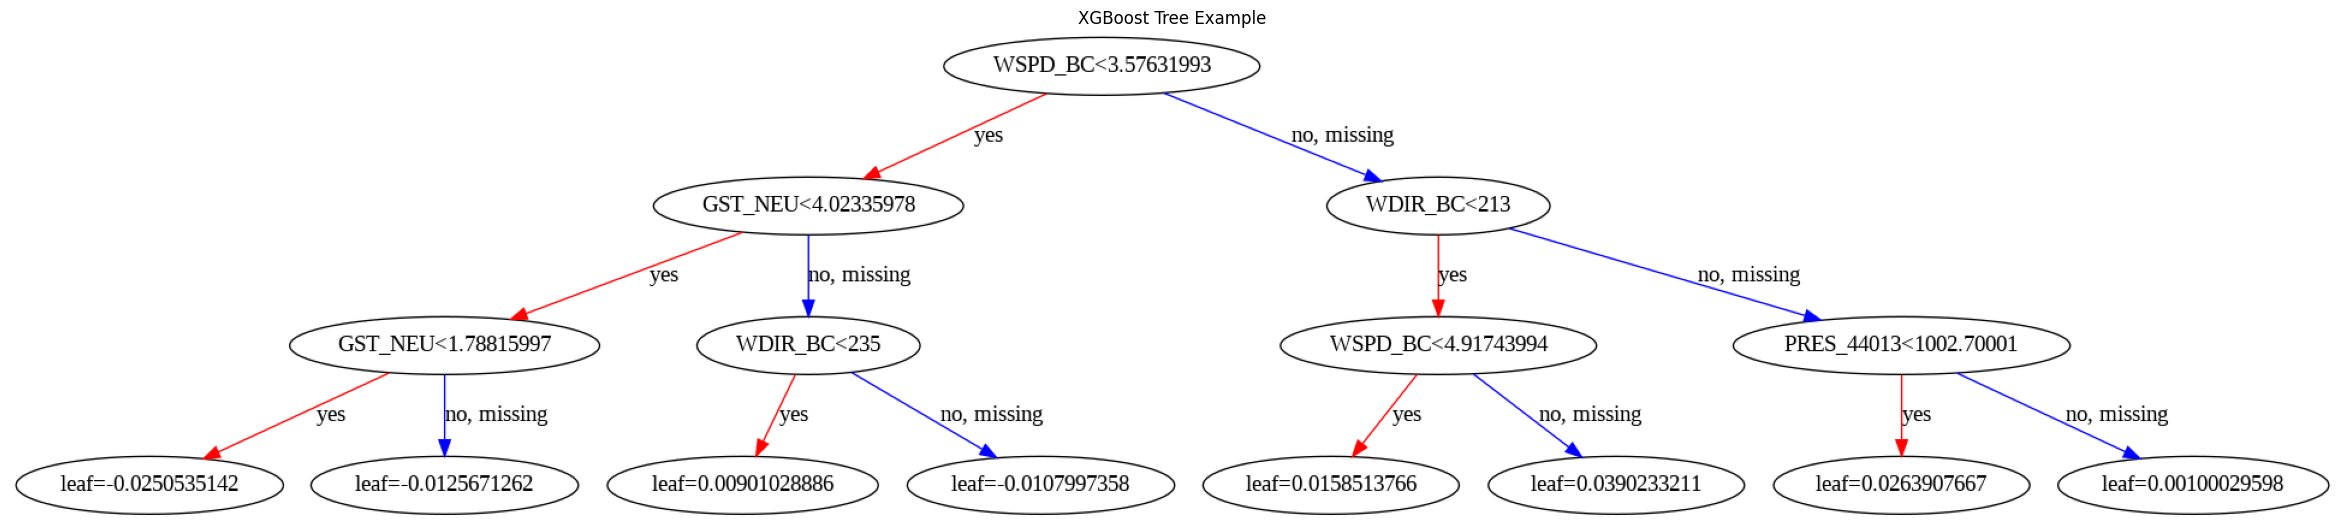

In [ ]:


# make feature names on the booster and plot
booster = xgbr.get_booster()
booster.feature_names = features

# showing the tree example
fig, ax = plt.subplots(figsize=(30, 30))
xgb.plot_tree(booster, tree_idx=0, ax=ax)
plt.title('XGBoost Tree Example')
plt.show()

# Model exploration

Since BC dominates so heavily, and we have a lot of parameters, we wanted to see if the model was effected by getting rid of other stations, and wanted to be thorough, so the model tests over mulitple test / train splits.

In [ ]:


# what features to always include
common_features = ["hh", 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']

# features at each station to add and remove
station_core_features_map = {
    '44013': ['WDIR_44013', 'WSPD_44013', 'GST_44013', 'PRES_44013'],
    'BC': ['WDIR_BC', 'WSPD_BC', 'GST_BC', 'PRES_BC'],
    'NEU': ['WDIR_NEU', 'WSPD_NEU', 'GST_NEU', 'PRES_NEU'],
    'SWAMP': ['WDIR_SWAMP', 'WSPD_SWAMP', 'GST_SWAP', 'PRES_SWAMP']
}

# interaction terms that go with each station for season
season_interaction_terms_map = {
    'Season_Summer_WSPD_44013': ['44013'],
    'Season_Winter_WSPD_44013': ['44013'],
    'Season_Winter_WDIR_44013': ['44013'],
    'Season_Winter_WDIR_SWAMP': ['SWAMP'],
    'Season_Summer_WDIR_44013': ['44013']
}

# interaction terms that go with each station for WSPD
wspd_interaction_terms_map = {
    'WSPD_BC_WSPD_NEU': ['BC', 'NEU'],
    'WSPD_BC_WSPD_SWAMP': ['BC', 'SWAMP'],
    'WSPD_BC_WSPD_44013': ['BC', '44013'],
    'WSPD_NEU_WSPD_SWAMP': ['NEU', 'SWAMP'],
    'WSPD_NEU_WSPD_44013': ['NEU', '44013'],
    'WSPD_SWAMP_WSPD_44013': ['SWAMP', '44013']
}

all_station_ids = ['44013', 'BC', 'NEU', 'SWAMP']
all_model_results = []
num_splits = 50

# Iterate through all non-empty combinations of stations
for i in range(1, len(all_station_ids) + 1):
    for current_station_combination in itertools.combinations(all_station_ids, i):
        current_station_combination_list = list(current_station_combination)
        model_description = " + ".join(current_station_combination_list)
        model_name = f"Model ({model_description})"

        # Build feature list for the current model
        current_features = list(common_features)

        # Add core features for selected stations
        for station_id in current_station_combination_list:
            if station_id in station_core_features_map:
                current_features.extend(station_core_features_map[station_id])

        # Add season-related interaction terms if their dependent station(s) are included
        for term, required_stations in season_interaction_terms_map.items():
            if all(s in current_station_combination_list for s in required_stations):
                current_features.append(term)

        # Add WSPD inter-station interaction terms if both dependent stations are included
        for term, required_stations in wspd_interaction_terms_map.items():
            if all(s in current_station_combination_list for s in required_stations):
                current_features.append(term)

        # Ensure unique features and filter out any that might not exist in thedata
        final_features = []
        for feature in current_features:
            if feature in thedata.columns and feature not in final_features:
                final_features.append(feature)

        if not final_features:
            print(f"Skipping {model_name} as no valid features could be constructed.")
            continue

        # Prepare data for the model
        X_full = thedata[final_features]
        y_full = thedata["WSPD_offset_30min"]

        # Lists to store metrics for the current model across multiple splits
        temp_mses = []
        temp_rmses = []
        temp_maes = []
        temp_r2s = []

        for s in range(num_splits):
            X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=s)

            # Initialize and train the XGBoost model
            current_xgbr_model = xgb.XGBRegressor(
                objective='reg:squarederror',
                n_estimators=500,
                learning_rate=0.02,
                max_depth=3,
                subsample=0.9,
                colsample_bytree=0.8,
                min_child_weight=5,
                reg_lambda=2,
                early_stopping_rounds=30
            )
            current_xgbr_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

            # Make predictions
            y_pred = current_xgbr_model.predict(X_test)

            # Calculate evaluation metrics
            temp_mses.append(mean_squared_error(y_test, y_pred))
            temp_rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
            temp_maes.append(mean_absolute_error(y_test, y_pred))
            temp_r2s.append(r2_score(y_test, y_pred))

        # Calculate mean and std for each metric for the current model
        mean_mse = np.mean(temp_mses)
        std_mse = np.std(temp_mses)
        mean_rmse = np.mean(temp_rmses)
        std_rmse = np.std(temp_rmses)
        mean_mae = np.mean(temp_maes)
        std_mae = np.std(temp_maes)
        mean_r2 = np.mean(temp_r2s)
        std_r2 = np.std(temp_r2s)

        all_model_results.append({
            'Model Name': model_name,
            'Features Count': len(final_features),
            'Mean MSE': mean_mse,
            'Std MSE': std_mse,
            'Mean RMSE': mean_rmse,
            'Std RMSE': std_rmse,
            'Mean MAE': mean_mae,
            'Std MAE': std_mae,
            'Mean R2': mean_r2,
            'Std R2': std_r2,
            'Features List': final_features
        })

# Display results in a DataFrame for comparison
results_df = pd.DataFrame(all_model_results)
results_df_sorted = results_df.sort_values(by='Mean R2', ascending=False)

print("\n--- All Model Results (Mean and Std over 50 splits) ---")
display(results_df_sorted)


--- All Model Results (Mean and Std over 50 splits) ---


,Model Name,Features Count,Mean MSE,Std MSE,Mean RMSE,Std RMSE,Mean MAE,Std MAE,Mean R2,Std R2,Features List
14,Model (44013 + BC + NEU + SWAMP),20,0.782665,0.058247,0.884071,0.032933,0.688871,0.027218,0.594005,0.032377,"[hh, Season_Fall, Season_Spring, Season_Summer..."
11,Model (44013 + BC + SWAMP),16,0.802255,0.056849,0.895125,0.031716,0.698124,0.027100,0.583907,0.030679,"[hh, Season_Fall, Season_Spring, Season_Summer..."
10,Model (44013 + BC + NEU),17,0.807837,0.054883,0.898276,0.030615,0.702588,0.024940,0.580879,0.031730,"[hh, Season_Fall, Season_Spring, Season_Summer..."
13,Model (BC + NEU + SWAMP),16,0.811454,0.066494,0.900060,0.036698,0.700943,0.029175,0.579231,0.034483,"[hh, Season_Fall, Season_Spring, Season_Summer..."
4,Model (44013 + BC),13,0.825847,0.056204,0.908234,0.030956,0.710621,0.024876,0.571622,0.031220,"[hh, Season_Fall, Season_Spring, Season_Summer..."
8,Model (BC + SWAMP),12,0.832804,0.065023,0.911895,0.035374,0.711702,0.028836,0.568172,0.033459,"[hh, Season_Fall, Season_Spring, Season_Summer..."
7,Model (BC + NEU),13,0.859292,0.064400,0.926338,0.034488,0.725763,0.026809,0.554357,0.033954,"[hh, Season_Fall, Season_Spring, Season_Summer..."
1,Model (BC),9,0.884326,0.064334,0.939770,0.034046,0.736927,0.026712,0.541447,0.033110,"[hh, Season_Fall, Season_Spring, Season_Summer..."
12,Model (44013 + NEU + SWAMP),16,0.885170,0.069097,0.940119,0.036685,0.729953,0.027535,0.541102,0.034468,"[hh, Season_Fall, Season_Spring, Season_Summer..."
9,Model (NEU + SWAMP),12,0.951748,0.083738,0.974650,0.042501,0.757274,0.034600,0.506711,0.040244,"[hh, Season_Fall, Season_Spring, Season_Summer..."


### Incorporating Uncertainty: Prediction Intervals from Residuals (Post-hoc)

This method uses the standard deviation of the residuals from a standard (mean-predicting) regression model to estimate prediction intervals. It's a simpler approach but assumes that residuals are normally distributed and homoscedastic (have constant variance).

We will use the residuals calculated earlier (`residuals = y_test_df - y_pred`) from your initial `xgbr` model.

In [ ]:
# Calculate the standard deviation of the residuals
std_residuals = np.std(residuals)

# For a 95% prediction interval, a ~1.96 standard deviations is typically used.
# You can adjust this multiplier for different confidence levels
confidence_level_multiplier = 1.96 # For 95% CI

# Calculate the margin of error
margin_of_error = confidence_level_multiplier * std_residuals

# Create prediction intervals
y_pred_lower = y_pred - margin_of_error
y_pred_upper = y_pred + margin_of_error

# Display the first few predictions with intervals
print("\nFirst 5 predictions with 95% prediction intervals (from residuals):")
predictions_with_intervals_df = pd.DataFrame({
    'Actual': y_test_df.head(5).values,
    'Predicted': y_pred[:5],
    'Lower_Bound': y_pred_lower[:5],
    'Upper_Bound': y_pred_upper[:5]
})
display(predictions_with_intervals_df)



First 5 predictions with 95% prediction intervals (from residuals):


,Actual,Predicted,Lower_Bound,Upper_Bound
0,1.730556,1.809599,0.105389,3.513809
1,2.772222,2.505510,0.801300,4.209720
2,2.088889,3.372357,1.668147,5.076567
3,0.969444,1.842684,0.138474,3.546894
4,4.972222,2.955020,1.250810,4.659230


### Visualizing Prediction Intervals from Residuals

This plot shows the actual values, the point predictions from the standard XGBoost model, and the calculated 95% prediction intervals based on residual analysis.

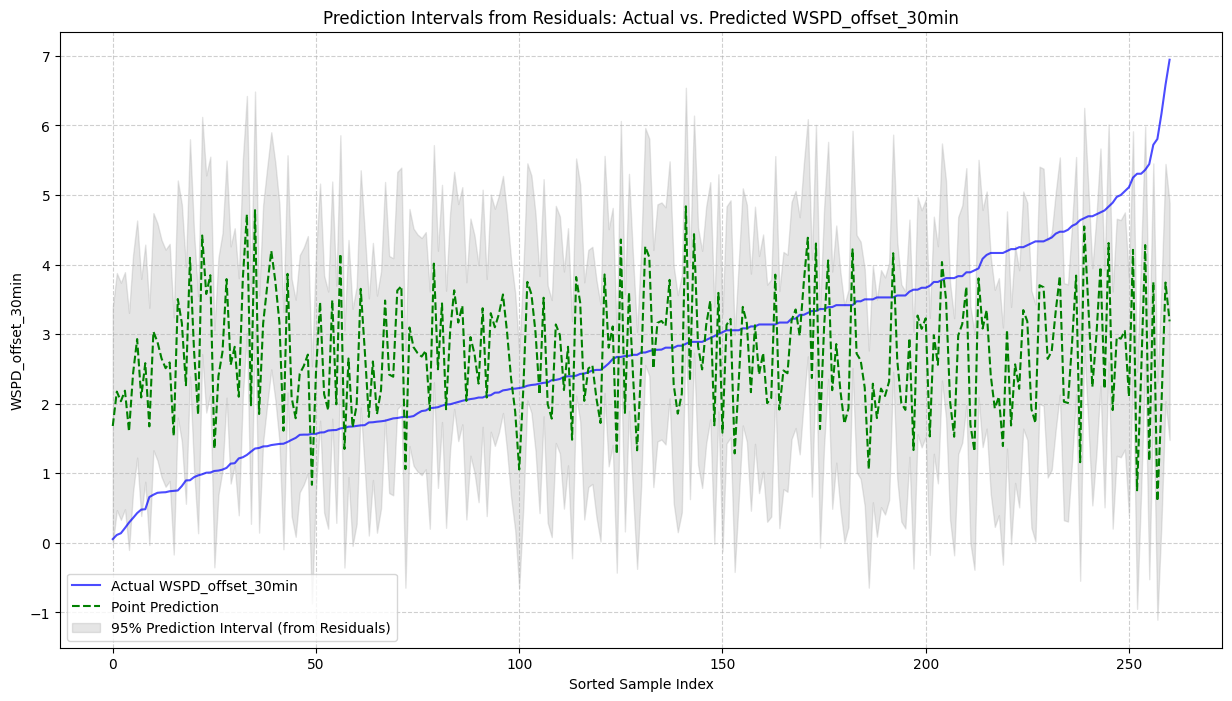

In [ ]:
# Combine predictions, intervals, and actual values for plotting
plot_df_residuals = pd.DataFrame({
    'Actual': y_test_df,
    'Predicted': y_pred,
    'Lower_Bound': y_pred_lower,
    'Upper_Bound': y_pred_upper
}).sort_values(by='Actual').reset_index(drop=True)

plt.figure(figsize=(15, 8))
plt.plot(plot_df_residuals.index, plot_df_residuals['Actual'], label='Actual WSPD_offset_30min', color='blue', alpha=0.7)
plt.plot(plot_df_residuals.index, plot_df_residuals['Predicted'], label='Point Prediction', color='green', linestyle='--')
plt.fill_between(plot_df_residuals.index, plot_df_residuals['Lower_Bound'], plot_df_residuals['Upper_Bound'], color='gray', alpha=0.2, label='95% Prediction Interval (from Residuals)')

plt.title('Prediction Intervals from Residuals: Actual vs. Predicted WSPD_offset_30min')
plt.xlabel('Sorted Sample Index')
plt.ylabel('WSPD_offset_30min')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualizing Quantile Predictions

Visualization of actual values against the predicted lower, median, and upper bounds from the quantile regression, using the newly generated predictions.

Training lower quantile model (alpha=0.05)...
Training median quantile model (alpha=0.5)...
Training upper quantile model (alpha=0.95)...

PREDICTION INTERVAL DIAGNOSTICS (90% PI)
Empirical coverage:    84.7%   (target: 90.0%)
Average PI width:      2.822 m/s
Median PI width:       2.807 m/s
Min PI width:          1.088 m/s
Max PI width:          4.812 m/s

Median-quantile model:  R² = 0.572, RMSE = 0.863 m/s


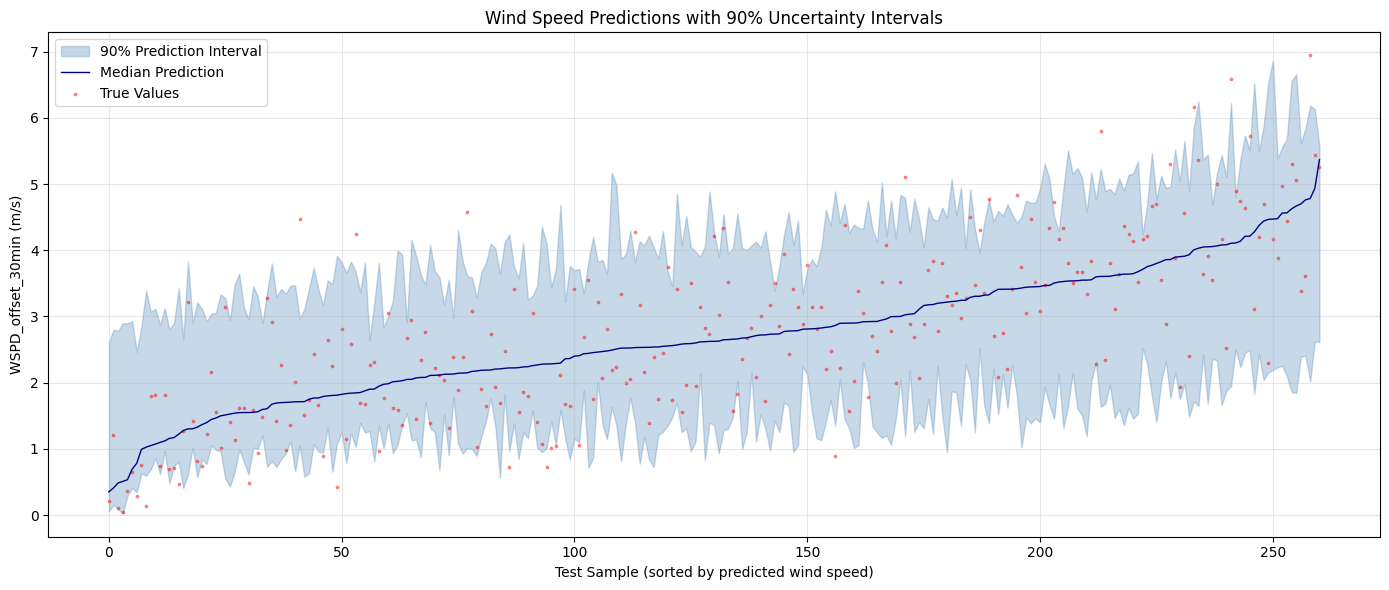

Nominal 10% PI -> empirical coverage 9.6%
Nominal 20% PI -> empirical coverage 19.5%
Nominal 30% PI -> empirical coverage 27.2%
Nominal 40% PI -> empirical coverage 38.7%
Nominal 50% PI -> empirical coverage 47.1%
Nominal 60% PI -> empirical coverage 56.7%
Nominal 70% PI -> empirical coverage 63.6%
Nominal 80% PI -> empirical coverage 75.9%
Nominal 90% PI -> empirical coverage 84.7%


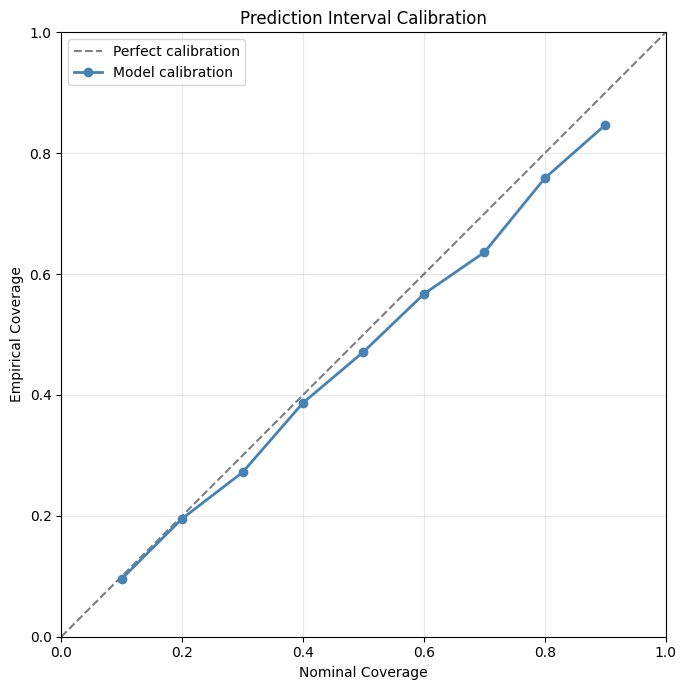

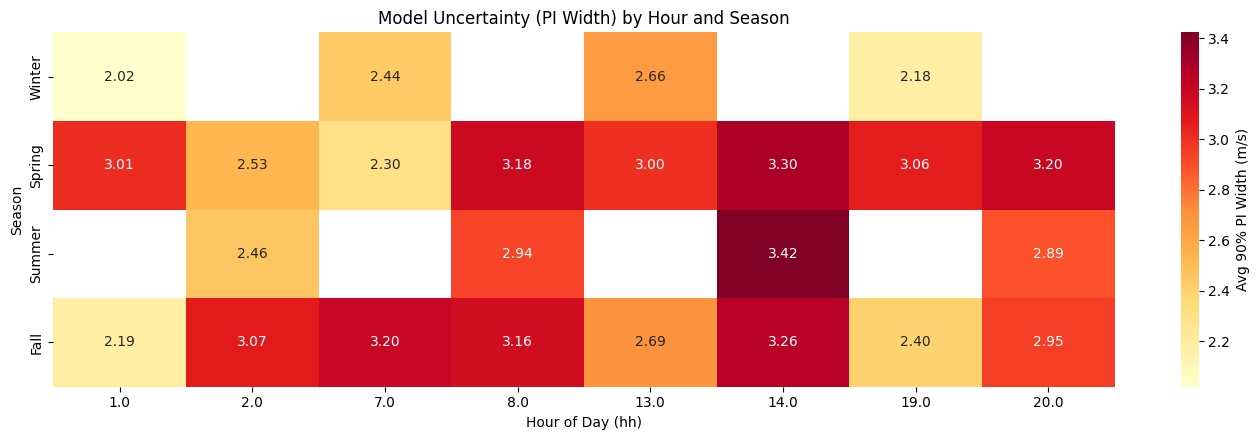

In [ ]:
# ============================================================
# QUANTILE REGRESSION FOR UNCERTAINTY ESTIMATES
# Trains 3 XGBoost models for the 5th, 50th, and 95th quantiles
# to produce 90% prediction intervals.
# ============================================================

# Shared hyperparameters (matching your main model, minus early stopping
# since quantile objectives don't support it cleanly)
quantile_params = dict(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=2,
    random_state=0
)

# Train one model per quantile
quantile_models = {}
for alpha, name in [(0.05, 'lower'), (0.5, 'median'), (0.95, 'upper')]:
    print(f"Training {name} quantile model (alpha={alpha})...")
    m = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=alpha,
        **quantile_params
    )
    m.fit(X_train_df, y_train_df)
    quantile_models[name] = m

# Generate predictions
y_lower = quantile_models['lower'].predict(X_test_df)
y_median = quantile_models['median'].predict(X_test_df)
y_upper = quantile_models['upper'].predict(X_test_df)

# ------------------------------------------------------------
# Diagnostic metrics for the prediction intervals
# ------------------------------------------------------------
y_test_arr = y_test_df.values

# Empirical coverage: fraction of true values inside the interval
# A well-calibrated 90% PI should give coverage close to 0.90
coverage = np.mean((y_test_arr >= y_lower) & (y_test_arr <= y_upper))

# Average interval width: narrower = more confident model
avg_width = np.mean(y_upper - y_lower)

# Median interval width (less sensitive to outliers)
median_width = np.median(y_upper - y_lower)

print("\n" + "="*55)
print("PREDICTION INTERVAL DIAGNOSTICS (90% PI)")
print("="*55)
print(f"Empirical coverage:    {coverage:.1%}   (target: 90.0%)")
print(f"Average PI width:      {avg_width:.3f} m/s")
print(f"Median PI width:       {median_width:.3f} m/s")
print(f"Min PI width:          {(y_upper - y_lower).min():.3f} m/s")
print(f"Max PI width:          {(y_upper - y_lower).max():.3f} m/s")

# Median model performance — compare to your point-prediction R² of 0.620
median_rmse = np.sqrt(mean_squared_error(y_test_arr, y_median))
median_r2 = r2_score(y_test_arr, y_median)
print(f"\nMedian-quantile model:  R² = {median_r2:.3f}, RMSE = {median_rmse:.3f} m/s")

# ------------------------------------------------------------
# Visualization 1: Sorted predictions with uncertainty bands
# ------------------------------------------------------------
sort_idx = np.argsort(y_median)
plt.figure(figsize=(14, 6))
plt.fill_between(
    range(len(sort_idx)),
    y_lower[sort_idx],
    y_upper[sort_idx],
    alpha=0.3, color='steelblue', label='90% Prediction Interval'
)
plt.plot(range(len(sort_idx)), y_median[sort_idx],
         color='navy', linewidth=1, label='Median Prediction')
plt.scatter(range(len(sort_idx)), y_test_arr[sort_idx],
            s=3, color='red', alpha=0.4, label='True Values')
plt.xlabel('Test Sample (sorted by predicted wind speed)')
plt.ylabel('WSPD_offset_30min (m/s)')
plt.title('Wind Speed Predictions with 90% Uncertainty Intervals')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 2: Calibration plot — does the model deliver
# the coverage it promises across different confidence levels?
# ------------------------------------------------------------
# Retrain quickly for a few more quantile levels to check calibration
calibration_alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
empirical_coverages = []

for nominal in calibration_alphas:
    lower_q = (1 - nominal) / 2
    upper_q = 1 - lower_q

    m_lo = xgb.XGBRegressor(objective='reg:quantileerror',
                            quantile_alpha=lower_q, **quantile_params)
    m_hi = xgb.XGBRegressor(objective='reg:quantileerror',
                            quantile_alpha=upper_q, **quantile_params)
    m_lo.fit(X_train_df, y_train_df)
    m_hi.fit(X_train_df, y_train_df)

    lo_pred = m_lo.predict(X_test_df)
    hi_pred = m_hi.predict(X_test_df)
    emp = np.mean((y_test_arr >= lo_pred) & (y_test_arr <= hi_pred))
    empirical_coverages.append(emp)
    print(f"Nominal {nominal:.0%} PI -> empirical coverage {emp:.1%}")

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.plot(calibration_alphas, empirical_coverages,
         marker='o', linewidth=2, color='steelblue', label='Model calibration')
plt.xlabel('Nominal Coverage')
plt.ylabel('Empirical Coverage')
plt.title('Prediction Interval Calibration')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('square')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 3: How does uncertainty vary by hour and season?
# (This is the most interesting one for your report — connects
#  back to your hour × season EDA)
# ------------------------------------------------------------
pi_widths = y_upper - y_lower
uncertainty_df = X_test_df.copy()
uncertainty_df['pi_width'] = pi_widths

# Reconstruct season label from one-hot columns
season_onehot = ['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']
uncertainty_df['Season'] = uncertainty_df[season_onehot].idxmax(axis=1).str.replace('Season_', '')

# Heatmap: average PI width by hour and season
pi_pivot = uncertainty_df.pivot_table(
    index='Season', columns='hh', values='pi_width', aggfunc='mean'
).reindex(['Winter', 'Spring', 'Summer', 'Fall'])

plt.figure(figsize=(14, 4.5))
sns.heatmap(pi_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Avg 90% PI Width (m/s)'})
plt.title('Model Uncertainty (PI Width) by Hour and Season')
plt.xlabel('Hour of Day (hh)')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

The following section is being run for interpretability metrics, i.e. specifically SHAP. Otherwise known as Shapley Additive exPlanations for model, it goes beyond XGBoost's built-in feature_importances_ by showing the *direction* of each feature's effect push prediction up vs. down, how effects vary across the data, and explanations for individual predictions.

Baseline (expected) prediction: 2.717 m/s
SHAP values shape: (261, 21)
(one SHAP value per feature for each of 261 test samples)

Plot 1: SHAP Summary (Beeswarm) — global feature impact + direction


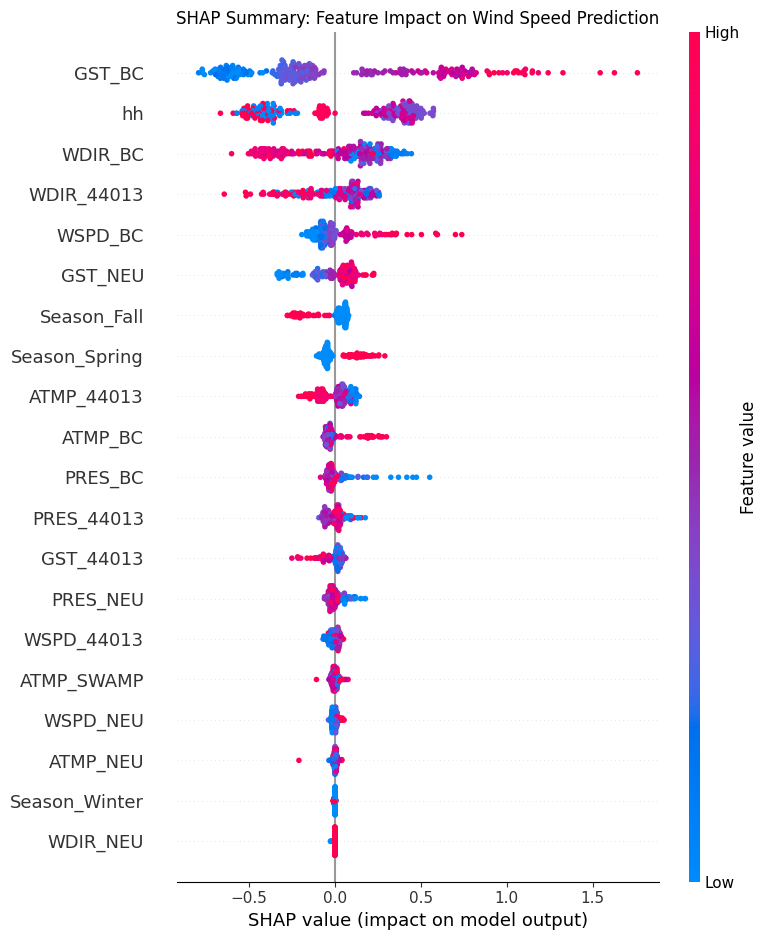


Plot 2: SHAP Bar Plot — mean absolute SHAP value per feature


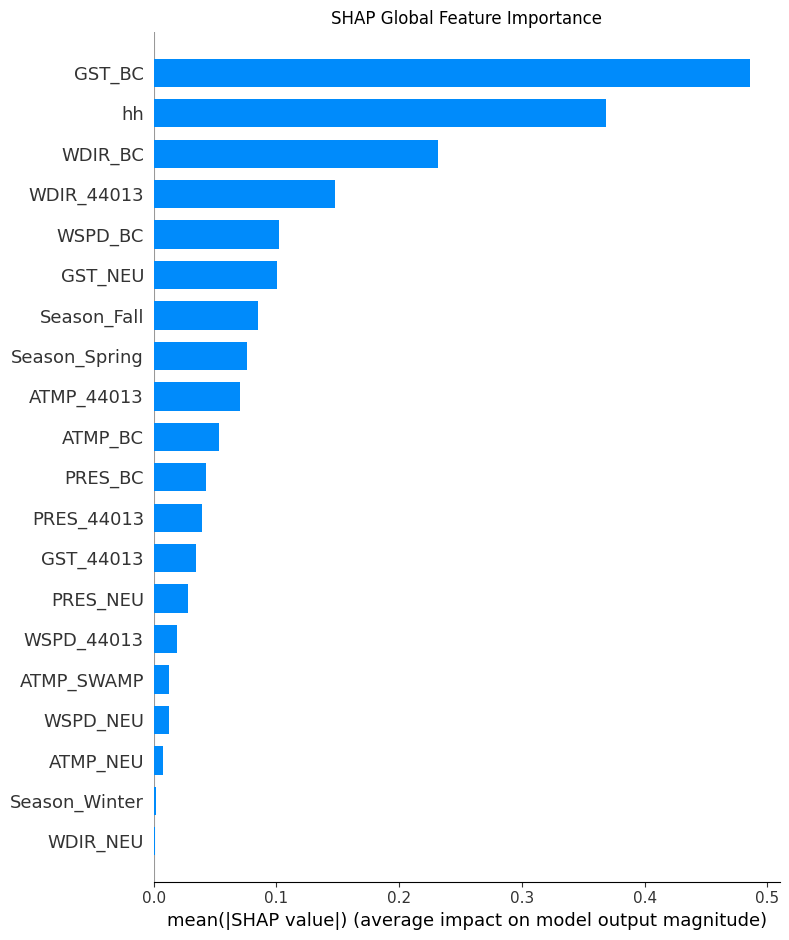


Plot 3: SHAP Dependence Plot for top feature: GST_BC


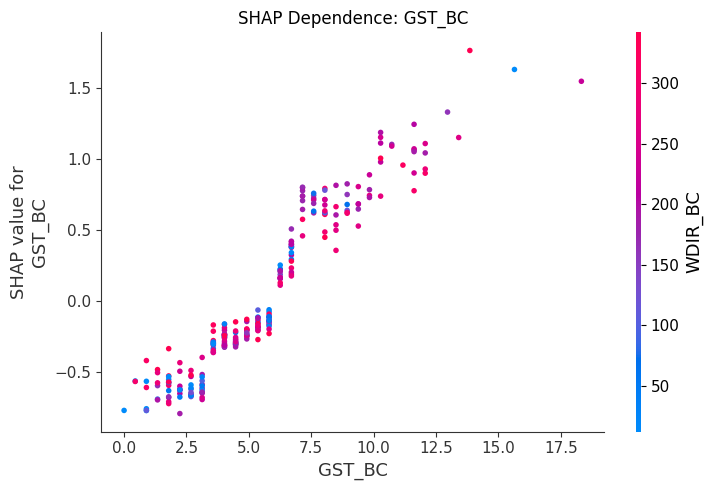


Plot 4: SHAP Dependence Plot for hour of day (hh)


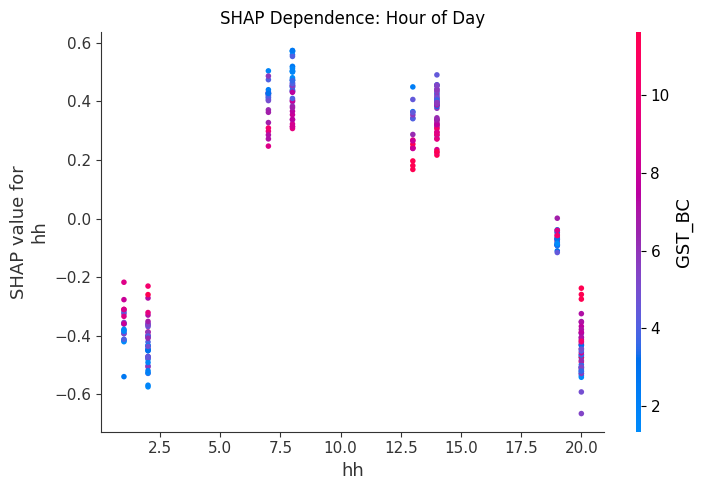


Plot 5: SHAP Waterfall — explaining sample #36
  Predicted wind speed: 5.453 m/s
  Actual wind speed:    5.250 m/s
  Baseline:             2.717 m/s


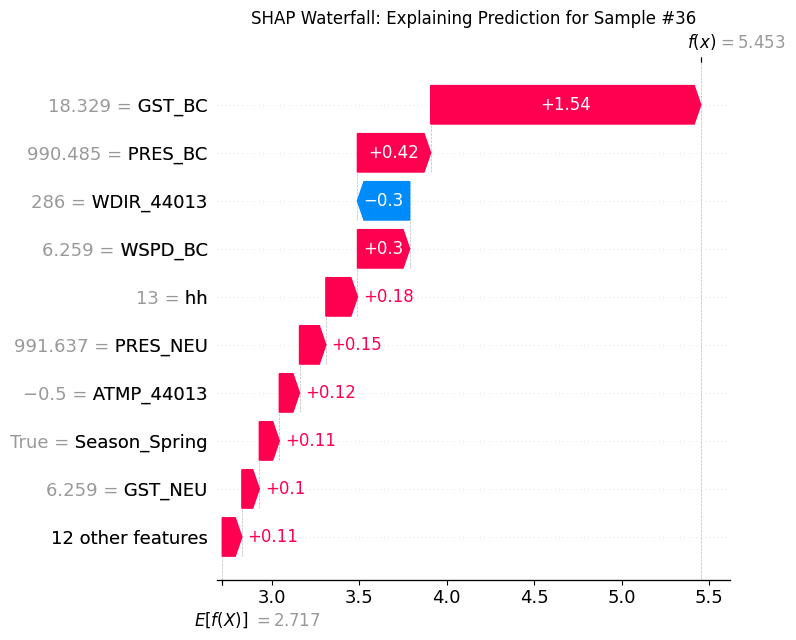


Comparison: XGBoost feature_importances_ vs. SHAP


,Feature,XGBoost Importance,Mean |SHAP|
7,GST_BC,0.253695,0.485998
0,hh,0.094670,0.368888
5,WDIR_BC,0.055652,0.231370
1,WDIR_44013,0.045077,0.147651
6,WSPD_BC,0.093523,0.101788
11,GST_NEU,0.057072,0.100341
13,Season_Fall,0.059541,0.084622
14,Season_Spring,0.051394,0.076212
17,ATMP_44013,0.023934,0.070070
18,ATMP_BC,0.019338,0.053342


In [ ]:
# SHAP

import shap

# TreeExplainer is fast + exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgbr)
shap_values = explainer.shap_values(X_test_df)

# The "baseline" prediction — average model output across the training set
print(f"Baseline (expected) prediction: {explainer.expected_value:.3f} m/s")
print(f"SHAP values shape: {shap_values.shape}")
print(f"(one SHAP value per feature for each of {shap_values.shape[0]} test samples)\n")

# ------------------------------------------------------------
# Plot 1: SHAP Summary Plot (beeswarm) — GLOBAL view
# Each dot = one prediction. x-axis = SHAP value (impact on output).
# Color = feature value (red high, blue low).
# Features ordered by overall importance.
# ------------------------------------------------------------
print("Plot 1: SHAP Summary (Beeswarm) — global feature impact + direction")
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Summary: Feature Impact on Wind Speed Prediction')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: SHAP Bar Plot — clean global importance ranking
# Mean absolute SHAP value per feature.
# Comparable to your existing feature_importances_ plot but more reliable.
# ------------------------------------------------------------
print("\nPlot 2: SHAP Bar Plot — mean absolute SHAP value per feature")
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: Dependence Plot for the top feature
# Shows the relationship between a feature's value and its SHAP value.
# Color = automatically selected interacting feature.
# Reveals nonlinearities and feature interactions the model learned.
# ------------------------------------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X_test_df.columns[top_feature_idx]

print(f"\nPlot 3: SHAP Dependence Plot for top feature: {top_feature_name}")
shap.dependence_plot(top_feature_name, shap_values, X_test_df, show=False)
plt.title(f'SHAP Dependence: {top_feature_name}')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 4: Dependence Plot for hour of day (hh) — domain-relevant
# Shows how time of day affects predictions, accounting for interactions
# (likely with seasonal or weather variables).
# ------------------------------------------------------------
if 'hh' in X_test_df.columns:
    print("\nPlot 4: SHAP Dependence Plot for hour of day (hh)")
    shap.dependence_plot('hh', shap_values, X_test_df, show=False)
    plt.title('SHAP Dependence: Hour of Day')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 5: Waterfall Plot — explanation for a SINGLE prediction
# Picks the test sample where the model was most confident in a HIGH wind
# prediction. Great for the report — shows the local explanation story.
# ------------------------------------------------------------
y_pred = xgbr.predict(X_test_df)
sample_idx = int(np.argmax(y_pred))  # highest predicted wind speed

print(f"\nPlot 5: SHAP Waterfall — explaining sample #{sample_idx}")
print(f"  Predicted wind speed: {y_pred[sample_idx]:.3f} m/s")
print(f"  Actual wind speed:    {y_test_df.iloc[sample_idx]:.3f} m/s")
print(f"  Baseline:             {explainer.expected_value:.3f} m/s")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[sample_idx].values,
        feature_names=X_test_df.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall: Explaining Prediction for Sample #{sample_idx}')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compare SHAP vs. XGBoost's built-in feature_importances_
# Useful diagnostic — they should rank features similarly,
# but SHAP is more theoretically principled.
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    'Feature': X_test_df.columns,
    'XGBoost Importance': xgbr.feature_importances_,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nComparison: XGBoost feature_importances_ vs. SHAP")
display(comparison_df)